# Santander Customer Transaction Prediction

## Ziel der Analyse

Ziel ist es, anhand von 200 anonymisierten numerischen Merkmalen vorherzusagen,
ob die Zielvariable `target` den Wert 0 oder 1 annimmt.

Dazu werden zunächst die Eigenschaften des Datensatzes untersucht. Anschließend
werden verschiedene Machine-Learning-Ansätze verglichen und schrittweise
optimiert.

## Fragestellungen

1. Welche Eigenschaften des Datensatzes sind für die Modellierung relevant?

2. Wie unterscheiden sich logistische Regression, kNN und XGBoost in ihrer
   Vorhersageleistung?

3. Kann die Modellleistung durch Dimensionsreduktion, Hyperparameteroptimierung
   oder zusätzliches Feature Engineering verbessert werden?

Da die Bedeutung der Merkmale `var_0` bis `var_199` nicht veröffentlicht ist,
werden die Ergebnisse ausschließlich statistisch und hinsichtlich ihrer
Vorhersageleistung interpretiert.

## 1. Setup und Reproduzierbarkeit

Zentrale Seeds, Datenpfade und Ausgabeverzeichnisse werden an einer Stelle
definiert. Ergebnisgrafiken werden zusätzlich als SVG und PNG gespeichert.

In [1]:
from pathlib import Path
from time import perf_counter
import hashlib
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Reproduzierbarkeit
RANDOM_STATE = 42
FINAL_HOLDOUT_RANDOM_STATE = 20260808
OUTER_SPLITS = 5
INNER_SPLITS = 2

# Datensatz
OPENML_ID = 45566
TARGET = "target"
FEATURE_COLUMNS = [f"var_{i}" for i in range(200)]

# Projektstruktur
PROJECT_ROOT = Path.cwd().resolve()
PROJECT_MARKERS = [
    "Bewertungshinweise_ADA.pdf",
    "Projekt_Kaggle_Santander.pdf",
]
missing_project_markers = [
    marker
    for marker in PROJECT_MARKERS
    if not (PROJECT_ROOT / marker).is_file()
]

if missing_project_markers:
    raise RuntimeError(
        "Das Notebook muss aus dem ADA-Projektordner gestartet werden. "
        f"Aktuelles Arbeitsverzeichnis: {PROJECT_ROOT}. "
        "Fehlende Projektmarker: " + ", ".join(missing_project_markers)
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# In der finalen Abgabe wird der Holdout ausschließlich in Abschnitt 17 ausgewertet.
ALLOW_FINAL_HOLDOUT_EVALUATION = True

def save_figure(fig, name):
    """Speichert eine Abbildung als SVG und PNG."""
    fig.savefig(FIGURE_DIR / f"{name}.svg", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=300, bbox_inches="tight")


versions = pd.DataFrame({
    "Software": ["Python", "pandas", "NumPy", "SciPy", "Matplotlib", "scikit-learn"],
    "Version": [
        platform.python_version(),
        pd.__version__,
        np.__version__,
        scipy.__version__,
        matplotlib.__version__,
        sklearn.__version__,
    ],
})
display(versions)


,Software,Version
0,Python,3.13.5
1,pandas,3.0.5
2,NumPy,2.5.1
3,SciPy,1.18.0
4,Matplotlib,3.11.1
5,scikit-learn,1.9.0


## 2. Daten laden

Der Datensatz wird bevorzugt aus einer lokalen Datei geladen. Falls keine
passende Datei vorhanden ist, wird die OpenML-Version mit der Data ID `45566`
verwendet.

Nach dem Laden wird geprüft, ob die erwarteten 200 Features `var_0` bis
`var_199` sowie die Zielvariable `target` vollständig vorhanden sind.

In [2]:
from scipy.io import arff
from sklearn.datasets import fetch_openml


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def candidate_data_paths():
    roots = [PROJECT_ROOT, PROJECT_ROOT.parent]
    relative_paths = [
        Path("data") / "dataset",
        Path("data") / "santander_customer_transaction_prediction.csv",
        Path("dataset"),
        Path("santander_customer_transaction_prediction.csv"),
    ]
    candidates = []
    for root in roots:
        for relative_path in relative_paths:
            path = (root / relative_path).resolve()
            if path not in candidates:
                candidates.append(path)
    return candidates


def load_local_table(path):
    with open(path, "rb") as handle:
        header = handle.read(2_000)

    if b"@relation" in header.lower() or b"@attribute" in header.lower():
        raw_data, _ = arff.loadarff(path)
        frame = pd.DataFrame(raw_data)
        for column in frame.select_dtypes(include="object").columns:
            frame[column] = frame[column].map(
                lambda value: value.decode("utf-8")
                if isinstance(value, bytes)
                else value
            )
        return frame, "ARFF"

    try:
        frame = pd.read_csv(path, low_memory=False)
    except UnicodeDecodeError:
        frame = pd.read_csv(path, encoding="latin1", low_memory=False)
    return frame, "CSV"


def load_santander_data(openml_id=OPENML_ID):
    for path in candidate_data_paths():
        if path.is_file():
            frame, detected_format = load_local_table(path)
            source = f"lokale Datei: {path.name}"
            file_hash = sha256_file(path)
            return frame, source, detected_format, file_hash

    openml_data = fetch_openml(data_id=openml_id, as_frame=True)
    frame = openml_data.frame.copy()
    return frame, f"OpenML Data ID {openml_id}", "OpenML", None


df, data_source, detected_format, local_sha256 = load_santander_data()

print("Datenquelle:", data_source)
print("Erkanntes Format:", detected_format)
print("Form:", df.shape)
display(df[FEATURE_COLUMNS[:15] + [TARGET]].head(5))

Datenquelle: lokale Datei: dataset
Erkanntes Format: ARFF
Form: (200000, 201)


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,target
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,0.5745,8.7989,False
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,8.4135,5.4345,False
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,-0.3249,-11.2648,14.1929,7.3124,7.5244,False
3,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,2.3061,2.8102,13.8463,11.9704,6.4569,False
4,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,-9.4458,-12.1419,13.8481,7.8895,7.7894,False


In [3]:
EXPECTED_ROWS = 200_000
EXPECTED_COLUMNS = FEATURE_COLUMNS + [TARGET]

missing_columns = [column for column in EXPECTED_COLUMNS if column not in df.columns]
unexpected_columns = [column for column in df.columns if column not in EXPECTED_COLUMNS]

if missing_columns:
    raise ValueError(f"Fehlende erwartete Spalten: {missing_columns[:10]}")
if unexpected_columns:
    raise ValueError(f"Unerwartete zusätzliche Spalten: {unexpected_columns[:10]}")
if len(df) != EXPECTED_ROWS:
    raise ValueError(f"Unerwartete Zeilenzahl: {len(df):,}; erwartet: {EXPECTED_ROWS:,}")

# Einheitliche binäre Zielcodierung unabhängig von lokaler/OpenML-Repräsentation.
target_normalized = df[TARGET].astype(str).str.strip().str.lower()
target_mapping = {"false": 0, "true": 1, "0": 0, "1": 1}
y = target_normalized.map(target_mapping)

if y.isna().any():
    unknown_values = df.loc[y.isna(), TARGET].unique().tolist()
    raise ValueError(f"Unbekannte target-Werte: {unknown_values}")

y = y.astype("int8")
X_float64 = df[FEATURE_COLUMNS].astype("float64")

manifest = pd.DataFrame({
    "Merkmal": [
        "Datenquelle",
        "Format",
        "Beobachtungen",
        "Features",
        "Zielvariable",
        "Lokale SHA-256",
    ],
    "Wert": [
        data_source,
        detected_format,
        len(df),
        len(FEATURE_COLUMNS),
        TARGET,
        local_sha256 if local_sha256 is not None else "n/a (OpenML)",
    ],
})

display(manifest)
print("Strukturprüfung erfolgreich: var_0 ... var_199 + target.")


,Merkmal,Wert
0,Datenquelle,lokale Datei: dataset
1,Format,ARFF
2,Beobachtungen,200000
3,Features,200
4,Zielvariable,target
5,Lokale SHA-256,06d49fb4b311c72a16686a0aeda4f15167872bf550cb8c...


Strukturprüfung erfolgreich: var_0 ... var_199 + target.


## 3. Speicherbedarf der Daten

Da der Datensatz vergleichsweise groß ist, wird geprüft, ob die numerischen
Features ohne relevanten Genauigkeitsverlust von `float64` auf `float32`
umgestellt werden können.

Dazu werden Speicherbedarf und maximale Abweichung nach der Konvertierung
verglichen.

In [4]:
memory_float64 = X_float64.memory_usage(deep=True).sum() / 1024**2
X = X_float64.astype("float32")
memory_float32 = X.memory_usage(deep=True).sum() / 1024**2

max_abs_conversion_error = (
    X_float64 - X.astype("float64")
).abs().to_numpy().max()

memory_saving = 100 * (1 - memory_float32 / memory_float64)

float32_summary = pd.DataFrame({
    "Kennzahl": [
        "RAM float64 [MiB]",
        "RAM float32 [MiB]",
        "RAM-Einsparung [%]",
    ],
    "Wert": [
        memory_float64,
        memory_float32,
        memory_saving,
    ],
})

display(float32_summary)

print(
    "Maximale absolute Abweichung:",
    f"{max_abs_conversion_error:.3e}",
)

# Ab hier wird float32 verwendet.
del X_float64

,Kennzahl,Wert
0,RAM float64 [MiB],305.1759
1,RAM float32 [MiB],152.5880
2,RAM-Einsparung [%],50.0000


Maximale absolute Abweichung: 3.796e-06


**Ergebnis:** Durch die Umstellung auf `float32` wird der Speicherbedarf um
etwa 50 % reduziert. Die größte Abweichung zu den ursprünglichen Werten beträgt
nur etwa `0,0000038` und ist damit sehr klein. Deshalb wird für die weiteren
Berechnungen `float32` verwendet.

## 4. Aufteilung in Development- und Holdout-Daten

Vor der weiteren Analyse werden 20 % der Daten stratifiziert als finaler
Holdout abgetrennt. Die übrigen 80 % bilden das Development-Set.

Das Development-Set wird für EDA, Cross-Validation, Modellwahl und
Hyperparameteroptimierung verwendet. Der Holdout wird erst nach der endgültigen
Modellwahl zur abschließenden Bewertung verwendet.

In [5]:
from sklearn.model_selection import train_test_split

all_indices = np.arange(len(X))
dev_indices, final_holdout_indices = train_test_split(
    all_indices,
    test_size=0.20,
    stratify=y,
    random_state=FINAL_HOLDOUT_RANDOM_STATE,
)

X_dev = X.iloc[dev_indices].reset_index(drop=True)
y_dev = y.iloc[dev_indices].reset_index(drop=True)
X_final_holdout = X.iloc[final_holdout_indices].reset_index(drop=True)
y_final_holdout = y.iloc[final_holdout_indices].reset_index(drop=True)

assert X_dev.shape == (160_000, 200)
assert X_final_holdout.shape == (40_000, 200)
assert set(dev_indices).isdisjoint(set(final_holdout_indices))

holdout_signature = hashlib.sha256(
    np.sort(final_holdout_indices).astype(np.int64).tobytes()
).hexdigest()[:16]

np.save(RESULT_DIR / "dev_indices.npy", dev_indices)
np.save(RESULT_DIR / "final_holdout_indices.npy", final_holdout_indices)

split_summary = pd.DataFrame({
    "Datenteil": ["Development", "Finaler Holdout"],
    "n": [len(X_dev), len(X_final_holdout)],
    "Verwendung": [
        "EDA, CV, Tuning, Modellwahl",
        "nur finale Evaluation",
    ],
})

display(split_summary)
print("Holdout-Seed:", FINAL_HOLDOUT_RANDOM_STATE)
print("Holdout-Signatur:", holdout_signature)
print("Finaler Holdout: bis Abschnitt 17 nicht verwendet")


,Datenteil,n,Verwendung
0,Development,160000,"EDA, CV, Tuning, Modellwahl"
1,Finaler Holdout,40000,nur finale Evaluation


Holdout-Seed: 20260808
Holdout-Signatur: 75ef349b3bf885fd
Finaler Holdout: bis Abschnitt 17 nicht verwendet


# 5. Explorative Datenanalyse auf den Entwicklungsdaten

Zunächst werden die Entwicklungsdaten genauer untersucht. Dabei geht es vor allem
um die Verteilung der Features, Unterschiede in den Skalen, die Klassenverteilung
und mögliche Zusammenhänge mit der Zielvariable.

## 5.1 Sind die Entwicklungsdaten vollständig und konsistent?

Zuerst wird geprüft, ob fehlende oder unendliche Werte, Duplikate,
doppelte Feature-Namen oder konstante Features vorhanden sind.

In [6]:
dev_with_target = X_dev.copy()
dev_with_target[TARGET] = y_dev.to_numpy()

missing_total = int(dev_with_target.isna().sum().sum())
inf_total = int(np.isinf(X_dev.to_numpy()).sum())
duplicate_rows = int(dev_with_target.duplicated().sum())
duplicate_feature_names = int(pd.Index(X_dev.columns).duplicated().sum())
constant_features = X_dev.columns[
    X_dev.nunique(dropna=False) <= 1
].tolist()

quality_summary = pd.DataFrame({
    "Prüfung": [
        "Fehlende Werte",
        "±Inf",
        "Doppelte Zeilen",
        "Doppelte Feature-Namen",
        "Konstante Features",
    ],
    "Anzahl": [
        missing_total,
        inf_total,
        duplicate_rows,
        duplicate_feature_names,
        len(constant_features),
    ],
})

display(quality_summary)

,Prüfung,Anzahl
0,Fehlende Werte,0
1,±Inf,0
2,Doppelte Zeilen,0
3,Doppelte Feature-Namen,0
4,Konstante Features,0


**Ergebnis:** Es gibt keine fehlenden oder unendlichen Werte, keine doppelten
Zeilen oder Feature-Namen und keine konstanten Features. Eine Imputation ist
daher nicht notwendig.

## 5.2 Wie unterscheiden sich Verteilungen und Skalen der Features?

Die Features werden hinsichtlich ihrer Streuung und Verteilung untersucht.
Besonders für kNN ist wichtig, ob sich die Skalen stark unterscheiden, da
Features mit großer Streuung sonst die Distanzberechnung stärker beeinflussen.

Zusätzlich wird geprüft, ob stark schiefe Verteilungen eine weitere
Transformation der Daten notwendig machen.

In [7]:
feature_stats = X_dev.describe().T
feature_stats["skewness"] = X_dev.skew()
feature_stats["kurtosis"] = X_dev.kurtosis()

stats_overview = pd.DataFrame({
    "Kennzahl": [
        "Feature-Mittelwert: Minimum", "Feature-Mittelwert: Median", "Feature-Mittelwert: Maximum",
        "Feature-Std: Minimum", "Feature-Std: Median", "Feature-Std: Maximum",
        "Schiefe: Minimum", "Schiefe: Median", "Schiefe: Maximum",
    ],
    "Wert": [
        feature_stats["mean"].min(), feature_stats["mean"].median(), feature_stats["mean"].max(),
        feature_stats["std"].min(), feature_stats["std"].median(), feature_stats["std"].max(),
        feature_stats["skewness"].min(), feature_stats["skewness"].median(), feature_stats["skewness"].max(),
    ],
})
display(stats_overview)
print(f"Verhältnis größte/kleinste Feature-Std: {feature_stats['std'].max() / feature_stats['std'].min():,.1f}×")


,Kennzahl,Wert
0,Feature-Mittelwert: Minimum,-16.5387
1,Feature-Mittelwert: Median,6.5846
2,Feature-Mittelwert: Maximum,24.5351
3,Feature-Std: Minimum,0.0072
4,Feature-Std: Median,3.9387
5,Feature-Std: Maximum,21.4089
6,Schiefe: Minimum,-0.3387
7,Schiefe: Median,0.0200
8,Schiefe: Maximum,0.2639


Verhältnis größte/kleinste Feature-Std: 2,981.7×


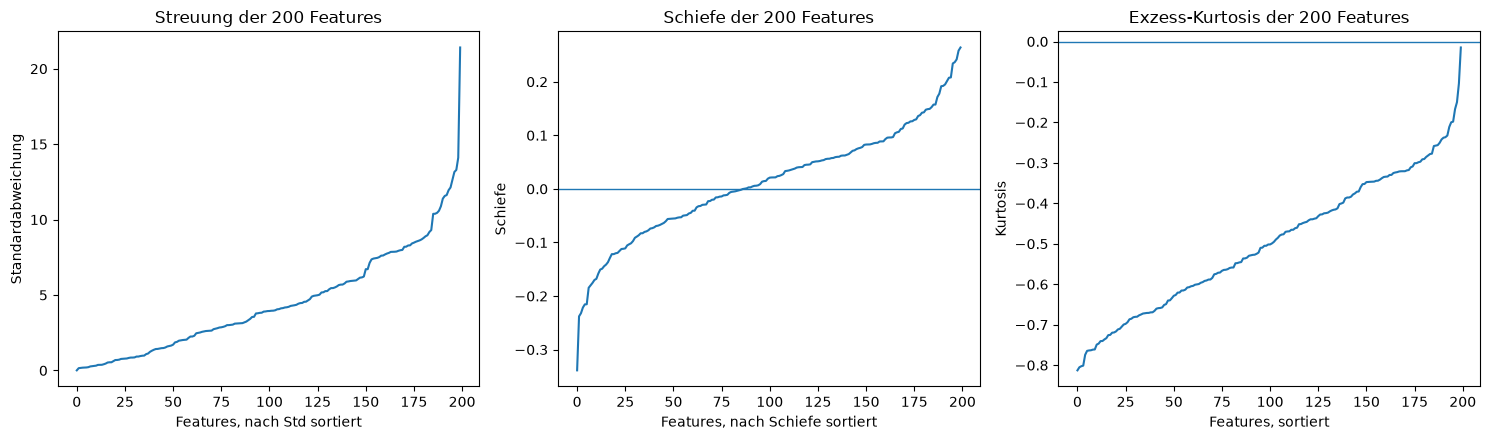

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

feature_stats["std"].sort_values().reset_index(drop=True).plot(ax=axes[0])
axes[0].set_title("Streuung der 200 Features")
axes[0].set_xlabel("Features, nach Std sortiert")
axes[0].set_ylabel("Standardabweichung")

feature_stats["skewness"].sort_values().reset_index(drop=True).plot(ax=axes[1])
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Schiefe der 200 Features")
axes[1].set_xlabel("Features, nach Schiefe sortiert")
axes[1].set_ylabel("Schiefe")

feature_stats["kurtosis"].sort_values().reset_index(drop=True).plot(ax=axes[2])
axes[2].axhline(0, linewidth=1)
axes[2].set_title("Exzess-Kurtosis der 200 Features")
axes[2].set_xlabel("Features, sortiert")
axes[2].set_ylabel("Kurtosis")

plt.tight_layout()
save_figure(fig, "eda_feature_scale_shape")
plt.show()


**Ergebnis:** Die Streuung der Features unterscheidet sich deutlich. Die
Standardabweichung reicht von etwa `0,007` bis `21,4`. Ohne Skalierung könnten
dadurch einzelne Features bei distanzbasierten Verfahren deutlich stärker ins
Gewicht fallen.

Die Schiefe ist dagegen insgesamt gering. Eine zusätzliche Transformation der
Verteilungen ist daher nicht notwendig.

Für Logistic Regression und kNN werden die Features skaliert. XGBoost benötigt
diese Skalierung nicht.

## 5.3 Wie ist die Zielvariable verteilt?

Als Nächstes wird untersucht, wie häufig die beiden Klassen in `target`
vorkommen. Eine starke Ungleichverteilung ist wichtig für die Wahl geeigneter
Bewertungsmetriken.

,Anzahl,Anteil [%]
False (0),143922,89.9513
True (1),16078,10.0488


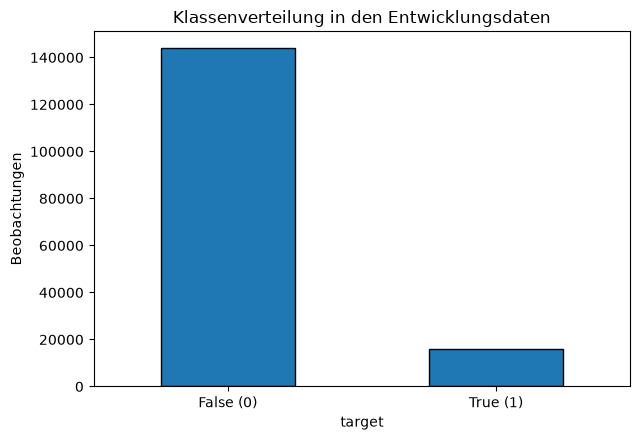

Positive Basisrate / AP-Referenz: 0.1005


In [9]:
target_table = pd.DataFrame({
    "Anzahl": y_dev.value_counts().sort_index(),
    "Anteil [%]": 100 * y_dev.value_counts(normalize=True).sort_index(),
})
target_table.index = ["False (0)", "True (1)"]
display(target_table)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
target_table["Anzahl"].plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("Klassenverteilung in den Entwicklungsdaten")
ax.set_xlabel("target")
ax.set_ylabel("Beobachtungen")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
save_figure(fig, "eda_target_distribution")
plt.show()

print(f"Positive Basisrate / AP-Referenz: {y_dev.mean():.4f}")


**Ergebnis:** Nur etwa `10,05 %` der Beobachtungen gehören zur positiven
Klasse. Der Datensatz ist damit deutlich unausgeglichen.

Eine reine Accuracy wäre deshalb wenig aussagekräftig. Für den Modellvergleich
wird vor allem die Average Precision (AP) verwendet. Eine uninformierte
Vorhersage erreicht hier ungefähr `0,1005` AP und dient als Referenz.
Die ROC-AUC wird zusätzlich berichtet.

## 5.4 Welche Features unterscheiden sich zwischen den beiden Klassen?

Für jedes Feature wird geprüft, wie stark es mit `target` zusammenhängt.
Dazu werden die Pearson-Korrelation und Cohen's d betrachtet.

Die Analyse soll zeigen, ob einzelne Features bereits eine deutliche
Trennung der beiden Klassen ermöglichen.

In [10]:
pearson_target = X_dev.corrwith(y_dev)
mask_negative = y_dev.eq(0)
mask_positive = y_dev.eq(1)

cohens_d = {}
for column in X_dev.columns:
    negative = X_dev.loc[mask_negative, column]
    positive = X_dev.loc[mask_positive, column]
    n0, n1 = len(negative), len(positive)
    s0, s1 = negative.std(ddof=1), positive.std(ddof=1)
    pooled_sd = np.sqrt(
        ((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2)
    )
    cohens_d[column] = (
        (positive.mean() - negative.mean()) / pooled_sd
        if pooled_sd > 0 else np.nan
    )

association = pd.DataFrame({
    "Pearson": pearson_target,
    "Cohen's d": pd.Series(cohens_d),
})
association["|Pearson|"] = association["Pearson"].abs()
association["|Cohen's d|"] = association["Cohen's d"].abs()

display(association.nlargest(15, "|Cohen's d|")[["Pearson", "Cohen's d"]])
max_abs_pearson = association["|Pearson|"].max()
max_abs_cohens_d = association["|Cohen's d|"].max()

print(f"Max |Pearson|: {max_abs_pearson:.4f}")
print(f"Max |Cohen's d|: {max_abs_cohens_d:.4f}")


,Pearson,Cohen's d
var_81,-0.0800,-0.2671
var_139,-0.0731,-0.2438
var_12,-0.0701,-0.2338
var_6,0.0693,0.2309
var_146,-0.0655,-0.2184
var_110,0.0647,0.2155
var_53,0.0636,0.2118
var_26,0.0627,0.2088
var_22,0.0617,0.2058
var_76,-0.0615,-0.2049


Max |Pearson|: 0.0800
Max |Cohen's d|: 0.2671


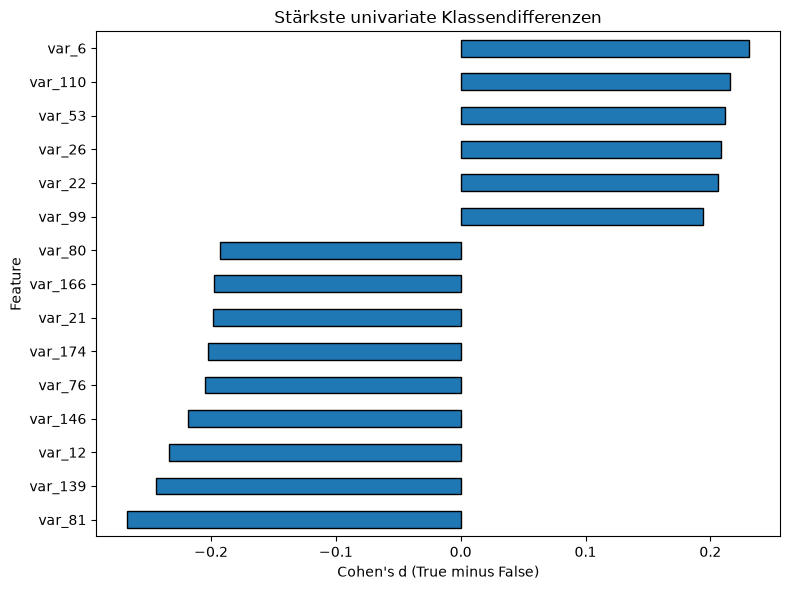

In [11]:
top_effects = association.nlargest(15, "|Cohen's d|").sort_values("Cohen's d")
fig, ax = plt.subplots(figsize=(8, 6))
top_effects["Cohen's d"].plot(kind="barh", ax=ax, edgecolor="black")
ax.set_title("Stärkste univariate Klassendifferenzen")
ax.set_xlabel("Cohen's d (True minus False)")
ax.set_ylabel("Feature")
plt.tight_layout()
save_figure(fig, "eda_top_cohens_d")
plt.show()


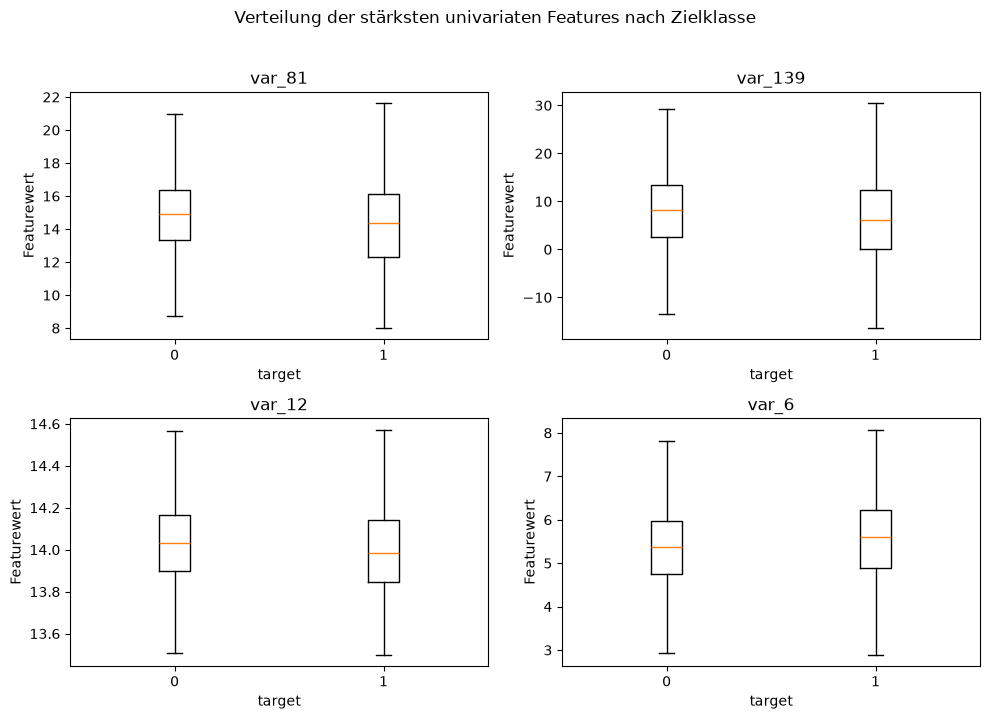

In [12]:
top_target_features = (
    association
    .nlargest(4, "|Cohen's d|")
    .index
    .tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, feature in zip(axes.ravel(), top_target_features):
    ax.boxplot(
        [
            X_dev.loc[mask_negative, feature],
            X_dev.loc[mask_positive, feature],
        ],
        tick_labels=["0", "1"],
        showfliers=False,
    )

    ax.set_title(feature)
    ax.set_xlabel("target")
    ax.set_ylabel("Featurewert")

fig.suptitle(
    "Verteilung der stärksten univariaten Features nach Zielklasse",
    y=1.02,
)

plt.tight_layout()
save_figure(fig, "eda_top_features_by_target")
plt.show()

**Ergebnis:** Kein einzelnes Feature zeigt einen starken Zusammenhang mit
der Zielvariable. Die größte absolute Pearson-Korrelation beträgt nur `0,0800`
und der größte absolute Wert von Cohen's d liegt bei `0,2671`.

`var_81` zeigt den stärksten einzelnen Unterschied zwischen den Klassen,
gefolgt unter anderem von `var_139`, `var_12` und `var_6`.

Die einzelnen Features liefern damit nur begrenzte Trenninformation. Für die
Modellierung werden deshalb weiterhin alle Features berücksichtigt und später
geprüft, ob ihre Kombination eine bessere Vorhersage ermöglicht.

## 5.5 Gibt es starke lineare Zusammenhänge zwischen den Features?

Als Nächstes wird geprüft, ob einzelne Features stark miteinander korrelieren.
Starke lineare Zusammenhänge könnten auf redundante Informationen hindeuten.

Dargestellt werden die 15 Featurepaare mit der größten absoluten
Pearson-Korrelation. Dabei wird die Diagonale ausgeschlossen und jedes
Featurepaar nur einmal berücksichtigt.

In [13]:
# Pearson-Korrelationen auf dem vollständigen Development-Set
feature_corr = X_dev.corr(method="pearson")

# Nur unterschiedliche Featurepaare betrachten; jedes Paar erscheint einmal.
upper_mask = np.triu(
    np.ones(feature_corr.shape, dtype=bool),
    k=1,
)

pairwise_corr = feature_corr.where(upper_mask).stack()

top_feature_correlations = (
    pairwise_corr
    .rename("Pearson r")
    .rename_axis(["Feature 1", "Feature 2"])
    .reset_index()
)
top_feature_correlations["|r|"] = (
    top_feature_correlations["Pearson r"].abs()
)
top_feature_correlations = (
    top_feature_correlations
    .sort_values("|r|", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

max_abs_feature_corr = float(top_feature_correlations["|r|"].iloc[0])

print(
    "Maximales |Pearson-r| zwischen verschiedenen Features: "
    f"{max_abs_feature_corr:.4f}"
)
display(top_feature_correlations)

top_feature_correlations.to_csv(
    RESULT_DIR / "eda_top_feature_correlations.csv",
    index=False,
)

Maximales |Pearson-r| zwischen verschiedenen Features: 0.0111


,Feature 1,Feature 2,Pearson r,|r|
0,var_26,var_139,-0.0111,0.0111
1,var_53,var_148,-0.0107,0.0107
2,var_81,var_174,0.0107,0.0107
3,var_146,var_169,0.0106,0.0106
4,var_183,var_189,0.0103,0.0103
5,var_91,var_165,-0.0097,0.0097
6,var_139,var_170,-0.0097,0.0097
7,var_37,var_129,0.0096,0.0096
8,var_81,var_165,0.0095,0.0095
9,var_26,var_166,-0.0093,0.0093


**Ergebnis:** Die Tabelle der 15 stärksten eindeutigen Featurepaare zeigt
durchgehend sehr schwache lineare Zusammenhänge. Die größte absolute
Pearson-Korrelation zwischen zwei verschiedenen Features beträgt nur `0,0111`.

Es gibt damit keinen Hinweis auf starke lineare Redundanz zwischen einzelnen
Featurepaaren. Eine korrelationsbasierte Entfernung von Features wird daher
nicht vorgenommen.

Nichtlineare oder gemeinsame Effekte mehrerer Features können dadurch jedoch
nicht ausgeschlossen werden.

## 5.6 Gibt es auffällige Ausreißer?

Mit der IQR-Regel wird geprüft, wie häufig Werte außerhalb des üblichen
Bereichs liegen.

Da die Features anonymisiert sind, können solche Werte nicht automatisch als
Fehler interpretiert werden.

,IQR-Ausreißeranteil [%]
var_179,0.7631
var_44,0.5750
var_93,0.4469
var_146,0.4094
var_192,0.3575
var_31,0.3206
var_133,0.3000
var_105,0.2919
var_38,0.2556
var_193,0.2462


Höchster Ausreißeranteil: var_179 mit 0.76 %


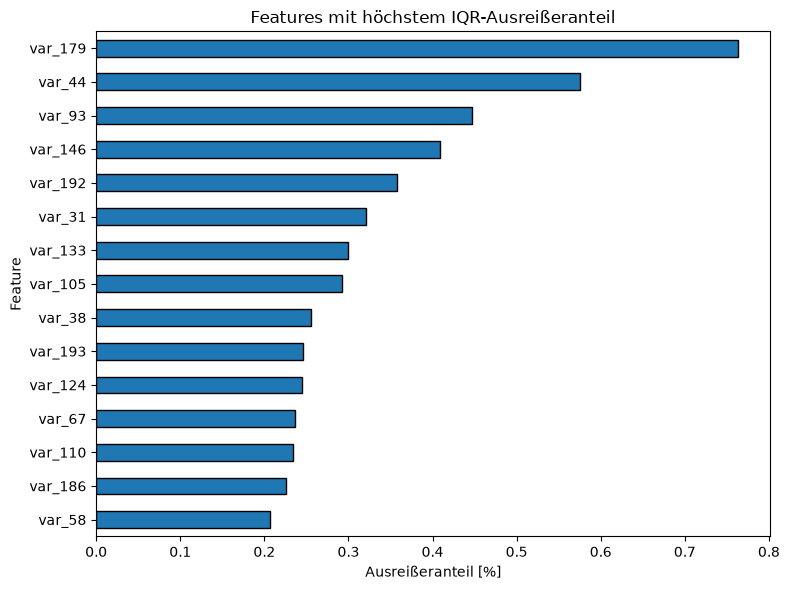

In [14]:
q1 = X_dev.quantile(0.25)
q3 = X_dev.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_rate = pd.Series({
    column: 100 * ((X_dev[column] < lower_bound[column]) | (X_dev[column] > upper_bound[column])).mean()
    for column in X_dev.columns
}).sort_values(ascending=False)

display(
    outlier_rate.head(15)
    .rename("IQR-Ausreißeranteil [%]")
    .to_frame()
)

max_outlier_feature = outlier_rate.idxmax()
max_outlier_rate = outlier_rate.max()

print(
    f"Höchster Ausreißeranteil: {max_outlier_feature} "
    f"mit {max_outlier_rate:.2f} %"
)

fig, ax = plt.subplots(figsize=(8, 6))

outlier_rate.head(15).sort_values().plot(
    kind="barh",
    ax=ax,
    edgecolor="black",
)

ax.set_title("Features mit höchstem IQR-Ausreißeranteil")
ax.set_xlabel("Ausreißeranteil [%]")
ax.set_ylabel("Feature")

plt.tight_layout()
save_figure(fig, "eda_outlier_rates")
plt.show()


**Ergebnis:** Auch beim auffälligsten Feature liegt der Anteil der nach der
IQR-Regel erkannten Ausreißer nur bei etwa `0,76 %`.

Es gibt damit keinen Hinweis auf ein allgemeines Ausreißerproblem. Da außerdem
nicht bekannt ist, welche Werte fachlich plausibel oder unplausibel wären,
werden keine Werte pauschal entfernt oder begrenzt.

## 5.7 Was folgt aus der EDA für die Modellierung?

Aus der EDA ergeben sich folgende Entscheidungen für die weitere Analyse:

- Eine Imputation ist nicht notwendig, da keine fehlenden oder unendlichen
  Werte vorhanden sind.
- Logistic Regression und kNN werden skaliert, da sich die Feature-Skalen
  stark unterscheiden.
- Wegen der unausgeglichenen Zielvariable werden stratifizierte Splits
  verwendet und vor allem die Average Precision (AP) zur Bewertung herangezogen.
- Es werden zunächst alle 200 Features beibehalten, da weder starke
  Feature-Feature-Korrelationen noch einzelne klar dominante Features
  gefunden wurden.
- Da einzelne Features nur begrenzte Trenninformation liefern, werden
  unterschiedliche multivariate Modelle verglichen.
- Ausreißer werden nicht pauschal entfernt oder begrenzt.
- Für kNN wird zusätzlich geprüft, ob PCA im hochdimensionalen
  Merkmalsraum die Vorhersage verbessert.

---

# 6. Evaluationsstrategie

Für den Modellvergleich wird eine stratifizierte 5-Fold-Cross-Validation auf
dem Development-Set verwendet. Dadurch wird jedes Modell auf mehreren
unterschiedlichen Trainings- und Validierungsaufteilungen bewertet.

Bei Modellen mit Hyperparameteroptimierung werden die Parameter nur innerhalb
des jeweiligen Trainingsfolds ausgewählt. Der zugehörige äußere
Validierungsfold wird erst danach zur Bewertung verwendet.

Als wichtigste Metrik wird die Average Precision (AP) verwendet, da die
positive Klasse nur etwa 10 % der Daten ausmacht. Zusätzlich wird die ROC-AUC
berichtet.

Für den Vergleich werden Mittelwert und Streuung der Ergebnisse über die fünf
äußeren Folds betrachtet.

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    ConfusionMatrixDisplay,
)

outer_cv = StratifiedKFold(
    n_splits=OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
outer_splits = list(outer_cv.split(X_dev, y_dev))

fold_manifest = pd.DataFrame([
    {
        "Fold": fold,
        "Train n": len(train_idx),
        "Validation n": len(validation_idx),
        "Train positiv [%]": 100 * y_dev.iloc[train_idx].mean(),
        "Validation positiv [%]": 100 * y_dev.iloc[validation_idx].mean(),
    }
    for fold, (train_idx, validation_idx) in enumerate(outer_splits, start=1)
])
display(fold_manifest)


def probability_metrics(y_true, probabilities):
    probabilities = np.asarray(probabilities, dtype=float)

    clipped_probabilities = np.clip(
        probabilities,
        1e-7,
        1 - 1e-7,
    )

    return {
        "AP": average_precision_score(y_true, probabilities),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "Log Loss": log_loss(y_true, clipped_probabilities),
        "Brier": brier_score_loss(y_true, probabilities),
    }


oof_predictions = pd.DataFrame(index=np.arange(len(X_dev)))
fold_results = []
model_details = {}


,Fold,Train n,Validation n,Train positiv [%],Validation positiv [%]
0,1,128000,32000,10.0492,10.0469
1,2,128000,32000,10.0492,10.0469
2,3,128000,32000,10.0484,10.0500
3,4,128000,32000,10.0484,10.0500
4,5,128000,32000,10.0484,10.0500


# 7. Dummy-Baseline

Bevor die eigentlichen Modelle verglichen werden, wird eine einfache
Dummy-Baseline berechnet. Sie verwendet keine Informationen aus den Features
und zeigt damit, welche Leistung ohne ein tatsächlich lernendes Modell zu
erwarten wäre.

In [16]:
from sklearn.dummy import DummyClassifier

model_name = "Dummy (Prior)"
oof = np.full(len(X_dev), np.nan)

for fold, (train_idx, validation_idx) in enumerate(outer_splits, start=1):
    model = DummyClassifier(strategy="prior")
    model.fit(
        X_dev.iloc[train_idx],
        y_dev.iloc[train_idx],
    )

    probabilities = model.predict_proba(
        X_dev.iloc[validation_idx]
    )[:, 1]

    oof[validation_idx] = probabilities

    fold_results.append({
        "Modell": model_name,
        "Fold": fold,
        **probability_metrics(
            y_dev.iloc[validation_idx],
            probabilities,
        ),
    })

oof_predictions[model_name] = oof

dummy_results = pd.DataFrame(
    [
        result
        for result in fold_results
        if result["Modell"] == model_name
    ]
)

dummy_summary = pd.DataFrame({
    "Metrik": ["Average Precision", "ROC-AUC"],
    "Mittelwert": [
        dummy_results["AP"].mean(),
        dummy_results["ROC-AUC"].mean(),
    ],
    "Standardabweichung": [
        dummy_results["AP"].std(),
        dummy_results["ROC-AUC"].std(),
    ],
})

display(dummy_summary)

,Metrik,Mittelwert,Standardabweichung
0,Average Precision,0.1005,0.0000
1,ROC-AUC,0.5000,0.0000


**Ergebnis:** Die Dummy-Baseline erreicht eine Average Precision von ungefähr
`0,1005` und eine ROC-AUC von `0,5`.

Damit entspricht ihre Leistung im Wesentlichen der positiven Basisrate des
Datensatzes. Die folgenden Modelle sollten diese Werte deutlich übertreffen,
damit die Features tatsächlich zusätzliche Vorhersageinformation liefern.

# 8. Einfluss der Trainingsmenge

Bevor die Modelle auf dem gesamten Development-Set trainiert und optimiert
werden, wird geprüft, wie sich die Vorhersageleistung mit zunehmender
Trainingsmenge verändert.

Dafür werden eine logistische Regression und eine feste XGBoost-Konfiguration
auf einem zusätzlichen stratifizierten Split des Development-Sets untersucht.
Die Validierungsdaten bleiben dabei für alle Trainingsgrößen gleich.

Diese Analyse dient nur zur Beurteilung des Einflusses der Trainingsmenge.
Der eigentliche Modellvergleich erfolgt anschließend mit der
5-Fold-Cross-Validation.

xgboost: 3.4.0


,Modell,Trainingsanteil,Train n,Train AP,Validation AP,Sekunden
0,Logistische Regression,0.1000,12800,0.5280,0.4743,0.4081
1,XGBoost-Pilot,0.1000,12800,0.9237,0.5018,8.8448
2,Logistische Regression,0.2500,32000,0.5328,0.4950,0.6028
3,XGBoost-Pilot,0.2500,32000,0.8145,0.5411,19.8477
4,Logistische Regression,0.5000,64000,0.5107,0.5008,0.8346
5,XGBoost-Pilot,0.5000,64000,0.7192,0.5435,23.2477
6,Logistische Regression,0.7500,96000,0.5127,0.5028,0.9511
7,XGBoost-Pilot,0.7500,96000,0.6784,0.5524,36.0820
8,Logistische Regression,1.0000,128000,0.5139,0.5025,1.9389
9,XGBoost-Pilot,1.0000,128000,0.6582,0.5495,48.3564


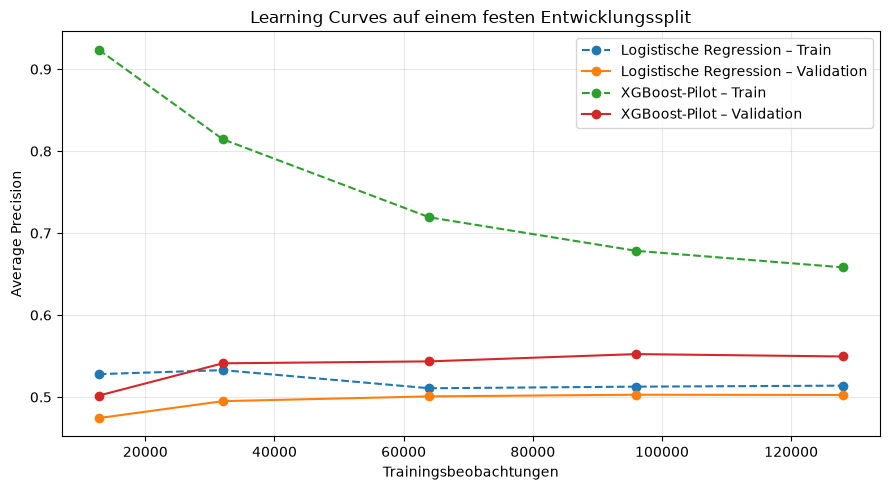

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import xgboost

print("xgboost:", xgboost.__version__)

learning_train_idx, learning_validation_idx = train_test_split(
    np.arange(len(X_dev)),
    test_size=0.20,
    stratify=y_dev,
    random_state=RANDOM_STATE + 600,
)
learning_fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
learning_records = []

for fraction in learning_fractions:
    if fraction < 1.0:
        sampled_train_idx, _ = train_test_split(
            learning_train_idx,
            train_size=fraction,
            stratify=y_dev.iloc[learning_train_idx],
            random_state=RANDOM_STATE + int(100 * fraction),
        )
    else:
        sampled_train_idx = learning_train_idx

    pilot_models = {
        "Logistische Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1_500, solver="lbfgs")),
        ]),
        "XGBoost-Pilot": XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            n_estimators=500,
            learning_rate=0.05,
            max_depth=3,
            min_child_weight=10,
            subsample=0.80,
            colsample_bytree=0.70,
            reg_alpha=0.1,
            reg_lambda=5.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

    for name, model in pilot_models.items():
        start = perf_counter()
        model.fit(X_dev.iloc[sampled_train_idx], y_dev.iloc[sampled_train_idx])
        train_probability = model.predict_proba(X_dev.iloc[sampled_train_idx])[:, 1]
        validation_probability = model.predict_proba(X_dev.iloc[learning_validation_idx])[:, 1]
        learning_records.append({
            "Modell": name,
            "Trainingsanteil": fraction,
            "Train n": len(sampled_train_idx),
            "Train AP": average_precision_score(y_dev.iloc[sampled_train_idx], train_probability),
            "Validation AP": average_precision_score(y_dev.iloc[learning_validation_idx], validation_probability),
            "Sekunden": perf_counter() - start,
        })

learning_results = pd.DataFrame(learning_records)
display(learning_results)

fig, ax = plt.subplots(figsize=(9, 5))
for name, group in learning_results.groupby("Modell"):
    ax.plot(group["Train n"], group["Train AP"], marker="o", linestyle="--", label=f"{name} – Train")
    ax.plot(group["Train n"], group["Validation AP"], marker="o", label=f"{name} – Validation")
ax.set_title("Learning Curves: Logistic Regression und XGBoost")
ax.set_xlabel("Trainingsbeobachtungen")
ax.set_ylabel("Average Precision")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure(fig, "learning_curves_pilot")
plt.show()


**Ergebnis:** Bei der logistischen Regression steigt die Validation-AP zunächst
von etwa `0,474` bei 12.800 Trainingsbeobachtungen auf ungefähr `0,503`.
Ab etwa 64.000 Beobachtungen verbessert sich die Leistung nur noch wenig.

Bei XGBoost steigt die Validation-AP von ungefähr `0,502` auf Werte um `0,55`.
Die höchste Validation-AP wird mit 96.000 Trainingsbeobachtungen erreicht;
bei 128.000 Beobachtungen liegt sie mit etwa `0,550` geringfügig darunter.
Der Verlauf zeigt damit einen deutlichen Nutzen zusätzlicher Trainingsdaten,
flacht bei größeren Stichproben jedoch ab.

Auffällig ist außerdem, dass bei XGBoost der Abstand zwischen Trainings- und
Validierungsleistung mit zunehmender Datenmenge deutlich kleiner wird. Bei
kleinen Trainingsmengen passt sich das Modell stärker an die Trainingsdaten an,
während die zusätzliche Datenmenge die Generalisierung verbessert.

Für die folgenden Modellvergleiche werden grundsätzlich die vollständigen
Trainingsanteile der jeweiligen Cross-Validation-Folds verwendet.

Eine Ausnahme bildet kNN: Aufgrund des deutlich höheren Rechenaufwands wird
das Training dort pro äußerem Fold auf 10.000 Beobachtungen begrenzt. Diese
Einschränkung wird bei der Interpretation der kNN-Ergebnisse berücksichtigt.

# 9. Logistische Regression

Die logistische Regression dient als lineares Referenzmodell. Da sich die
Feature-Skalen stark unterscheiden, werden die Daten innerhalb der Pipeline
standardisiert.

Die Regularisierungsstärke `C` und eine mögliche Klassengewichtung werden
innerhalb der Trainingsdaten ausgewählt. Bei der logistischen Regression
entsprechen kleinere Werte von `C` einer stärkeren Regularisierung.

In [18]:
from sklearn.model_selection import GridSearchCV

LOGISTIC_C_VALUES = [
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1.0,
    10.0,
]
model_name = "Logistische Regression"
oof = np.full(len(X_dev), np.nan)
selected_parameters = []

for fold, (train_idx, validation_idx) in enumerate(outer_splits, start=1):
    inner_cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=RANDOM_STATE + 100 + fold,
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="lbfgs",
            max_iter=1_500,
        )),
    ])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid={
            "model__C": LOGISTIC_C_VALUES,
            "model__class_weight": [None, "balanced"],
        },
        scoring="average_precision",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
    )
    search.fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])

    probabilities = search.predict_proba(X_dev.iloc[validation_idx])[:, 1]
    oof[validation_idx] = probabilities

    selected_parameters.append({
        "Fold": fold,
        **search.best_params_,
        "Inner AP": search.best_score_,
    })
    fold_results.append({
        "Modell": model_name,
        "Fold": fold,
        **probability_metrics(y_dev.iloc[validation_idx], probabilities),
    })

    print(
        f"Fold {fold}: AP={average_precision_score(y_dev.iloc[validation_idx], probabilities):.4f} | "
        f"{search.best_params_}"
    )

assert not np.isnan(oof).any()
oof_predictions[model_name] = oof
model_details[model_name] = pd.DataFrame(selected_parameters)

logistic_details_display = model_details[model_name].copy()

logistic_details_display["model__C"] = (
    logistic_details_display["model__C"]
    .map(lambda value: f"{value:.0e}")
)

logistic_details_display["model__class_weight"] = (
    logistic_details_display["model__class_weight"]
    .fillna("None")
)

display(logistic_details_display)

logistic_outer_results = (
    pd.DataFrame(fold_results)
    .query("Modell == @model_name")
    .drop_duplicates(
        subset=["Modell", "Fold"],
        keep="last",
    )
)

logistic_summary = pd.DataFrame({
    "Metrik": ["Average Precision", "ROC-AUC"],
    "Mittelwert": [
        logistic_outer_results["AP"].mean(),
        logistic_outer_results["ROC-AUC"].mean(),
    ],
    "Standardabweichung": [
        logistic_outer_results["AP"].std(),
        logistic_outer_results["ROC-AUC"].std(),
    ],
})

display(logistic_summary)

Fold 1: AP=0.5084 | {'model__C': 1e-05, 'model__class_weight': None}
Fold 2: AP=0.5083 | {'model__C': 1e-05, 'model__class_weight': None}
Fold 3: AP=0.5005 | {'model__C': 1e-08, 'model__class_weight': 'balanced'}
Fold 4: AP=0.5115 | {'model__C': 1e-06, 'model__class_weight': None}
Fold 5: AP=0.5094 | {'model__C': 1e-05, 'model__class_weight': None}


,Fold,model__C,model__class_weight,Inner AP
0,1,1e-05,None,0.5065
1,2,1e-05,None,0.5070
2,3,1e-08,balanced,0.5083
3,4,1e-06,None,0.5061
4,5,1e-05,None,0.5059


,Metrik,Mittelwert,Standardabweichung
0,Average Precision,0.5076,0.0042
1,ROC-AUC,0.8602,0.0016


**Ergebnis:** Die logistische Regression erreicht über die fünf äußeren Folds
eine mittlere Average Precision von `0,5076 ± 0,0042`.

Die ausgewählten Werte für `C` liegen durchgehend im stark regularisierten
Bereich. In drei der fünf Folds wurde `C = 1e-5` gewählt; die beiden übrigen
Folds wählten noch kleinere Werte. Eine zusätzliche Klassengewichtung wurde
nur in einem Fold ausgewählt.

Die ähnlichen AP-Werte der fünf äußeren Folds zeigen, dass die
Vorhersageleistung über die unterschiedlichen Datenaufteilungen hinweg stabil
ist. Gleichzeitig spricht die wiederholte Auswahl kleiner `C`-Werte dafür,
dass eine starke Regularisierung für dieses lineare Modell günstig ist.
Für eine zusätzliche Klassengewichtung zeigt sich dagegen kein konsistenter
Vorteil.

# 10. kNN und PCA

kNN basiert direkt auf Abständen zwischen Beobachtungen. Da die Daten 200
Features enthalten, wird geprüft, ob eine Dimensionsreduktion mit PCA die
Vorhersage verbessert.

Verglichen werden:

1. `StandardScaler → kNN`
2. `StandardScaler → PCA(50) → kNN`

Für beide Varianten werden `k` und die Gewichtung der Nachbarn innerhalb der
Trainingsdaten ausgewählt.

Da kNN bei diesem Datensatz sehr rechenintensiv ist, wird das Training pro
äußerem Fold auf 10.000 Beobachtungen begrenzt.

In [19]:
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier

KNN_K_VALUES = [21, 51, 101]
KNN_WEIGHT_VALUES = ["uniform", "distance"]
KNN_OUTER_TRAIN_CAP = 10_000
KNN_INNER_EVAL_SIZE = 5_000

KNN_CONFIGS = {
    "StandardScaler": {
        "preprocessor": StandardScaler(),
        "pipeline_steps": [("scaler", StandardScaler())],
        "metric": "euclidean",
    },
    "StandardScaler + PCA50": {
        "preprocessor": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=50, svd_solver="randomized", random_state=RANDOM_STATE)),
        ]),
        "pipeline_steps": [
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=50, svd_solver="randomized", random_state=RANDOM_STATE)),
        ],
        "metric": "euclidean",
    },
}


def neighbor_probabilities(distances, indices, train_targets, k, weights):
    local_distances = distances[:, :k]
    local_targets = np.asarray(train_targets)[indices[:, :k]]

    if weights == "uniform":
        return local_targets.mean(axis=1)

    zero_mask = local_distances <= 1e-12
    probabilities = np.empty(len(local_distances), dtype=float)
    rows_with_zero = zero_mask.any(axis=1)

    if rows_with_zero.any():
        zero_targets = np.where(
            zero_mask[rows_with_zero],
            local_targets[rows_with_zero],
            np.nan,
        )
        probabilities[rows_with_zero] = np.nanmean(zero_targets, axis=1)

    normal_rows = ~rows_with_zero
    inverse_distance = 1.0 / np.maximum(local_distances[normal_rows], 1e-12)
    probabilities[normal_rows] = (
        (inverse_distance * local_targets[normal_rows]).sum(axis=1)
        / inverse_distance.sum(axis=1)
    )
    return probabilities


def transform_float32(preprocessor, train_frame, validation_frame):
    train_transformed = preprocessor.fit_transform(train_frame)
    validation_transformed = preprocessor.transform(validation_frame)
    return (
        np.asarray(train_transformed, dtype="float32"),
        np.asarray(validation_transformed, dtype="float32"),
    )


In [20]:
KNN_MODEL_NAMES = {
    "StandardScaler": "kNN (Nested CV, Train-Cap 10k)",
    "StandardScaler + PCA50": "kNN + PCA50 (Nested CV, Train-Cap 10k)",
}

knn_oof = {
    model_name: np.full(len(X_dev), np.nan)
    for model_name in KNN_MODEL_NAMES.values()
}

knn_selected_parameters = {
    model_name: []
    for model_name in KNN_MODEL_NAMES.values()
}

knn_fold_records = []

for outer_fold, (outer_train_idx, outer_validation_idx) in enumerate(
    outer_splits,
    start=1,
):
    # Für beide Varianten wird exakt dieselbe stratifizierte
    # 10k-Trainingsstichprobe verwendet.
    if len(outer_train_idx) > KNN_OUTER_TRAIN_CAP:
        _, capped_outer_train_idx = train_test_split(
            outer_train_idx,
            test_size=KNN_OUTER_TRAIN_CAP,
            stratify=y_dev.iloc[outer_train_idx],
            random_state=RANDOM_STATE + 5_000 + outer_fold,
        )
    else:
        capped_outer_train_idx = outer_train_idx

    X_outer_train = (
        X_dev.iloc[capped_outer_train_idx]
        .reset_index(drop=True)
    )
    y_outer_train = (
        y_dev.iloc[capped_outer_train_idx]
        .reset_index(drop=True)
    )
    X_outer_validation = X_dev.iloc[outer_validation_idx]

    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + 200 + outer_fold,
    )

    # StandardScaler und PCA werden bewusst getrennt bewertet.
    for config_name, config in KNN_CONFIGS.items():
        model_name = KNN_MODEL_NAMES[config_name]
        candidate_records = []

        for inner_fold, (inner_train_idx, inner_validation_idx) in enumerate(
            inner_cv.split(X_outer_train, y_outer_train),
            start=1,
        ):
            if len(inner_validation_idx) > KNN_INNER_EVAL_SIZE:
                _, inner_validation_idx = train_test_split(
                    inner_validation_idx,
                    test_size=KNN_INNER_EVAL_SIZE,
                    stratify=y_outer_train.iloc[inner_validation_idx],
                    random_state=(
                        RANDOM_STATE
                        + 10_000 * outer_fold
                        + inner_fold
                    ),
                )

            preprocessor = clone(config["preprocessor"])

            X_inner_train, X_inner_validation = transform_float32(
                preprocessor,
                X_outer_train.iloc[inner_train_idx],
                X_outer_train.iloc[inner_validation_idx],
            )

            neighbor_model = NearestNeighbors(
                n_neighbors=max(KNN_K_VALUES),
                metric=config["metric"],
                algorithm="brute",
                n_jobs=-1,
            )

            neighbor_model.fit(X_inner_train)

            distances, indices = neighbor_model.kneighbors(
                X_inner_validation
            )

            inner_targets = (
                y_outer_train.iloc[inner_train_idx]
                .to_numpy()
            )
            validation_targets = (
                y_outer_train.iloc[inner_validation_idx]
            )

            for k in KNN_K_VALUES:
                for weights in KNN_WEIGHT_VALUES:
                    probabilities = neighbor_probabilities(
                        distances,
                        indices,
                        inner_targets,
                        k,
                        weights,
                    )

                    candidate_records.append({
                        "k": k,
                        "weights": weights,
                        "Inner Fold": inner_fold,
                        "AP": average_precision_score(
                            validation_targets,
                            probabilities,
                        ),
                    })

        candidate_records = pd.DataFrame(candidate_records)

        candidate_summary = (
            candidate_records
            .groupby(["k", "weights"], as_index=False)
            .agg(
                AP_Mittel=("AP", "mean"),
                AP_Std=("AP", "std"),
            )
            .sort_values(
                ["AP_Mittel", "AP_Std"],
                ascending=[False, True],
            )
        )

        best = candidate_summary.iloc[0]

        final_pipeline = Pipeline(
            config["pipeline_steps"]
            + [
                (
                    "model",
                    KNeighborsClassifier(
                        n_neighbors=int(best["k"]),
                        weights=best["weights"],
                        metric=config["metric"],
                        algorithm="brute",
                        n_jobs=-1,
                    ),
                )
            ]
        )

        final_pipeline.fit(
            X_outer_train,
            y_outer_train,
        )

        probabilities = final_pipeline.predict_proba(
            X_outer_validation
        )[:, 1]

        knn_oof[model_name][outer_validation_idx] = probabilities

        metrics = probability_metrics(
            y_dev.iloc[outer_validation_idx],
            probabilities,
        )

        record = {
            "Modell": model_name,
            "Fold": outer_fold,
            **metrics,
        }

        knn_fold_records.append(record)
        fold_results.append(record)

        knn_selected_parameters[model_name].append({
            "Fold": outer_fold,
            "k": int(best["k"]),
            "weights": best["weights"],
            "Inner AP": best["AP_Mittel"],
            "Outer-Train n": len(X_outer_train),
        })

        print(
            f"{model_name} | Fold {outer_fold}: "
            f"AP={metrics['AP']:.4f} | "
            f"k={int(best['k'])}, "
            f"weights={best['weights']}"
        )

# Ergebnisse beider Varianten speichern
for model_name, oof in knn_oof.items():
    assert not np.isnan(oof).any()

    oof_predictions[model_name] = oof
    model_details[model_name] = pd.DataFrame(
        knn_selected_parameters[model_name]
    )

    print(f"\n{model_name}")
    display(model_details[model_name])

# Direkter Outer-CV-Vergleich
knn_fold_results = pd.DataFrame(knn_fold_records)

knn_comparison = (
    knn_fold_results
    .groupby("Modell")
    .agg(
        AP_Mittel=("AP", "mean"),
        AP_Std=("AP", "std"),
        ROC_AUC_Mittel=("ROC-AUC", "mean"),
        ROC_AUC_Std=("ROC-AUC", "std"),
    )
    .sort_values("AP_Mittel", ascending=False)
)

display(knn_comparison)

# Gepaarte AP-Differenz auf denselben äußeren Folds
knn_pair = knn_fold_results.pivot(
    index="Fold",
    columns="Modell",
    values="AP",
)

knn_pair["Δ AP PCA - ohne PCA"] = (
    knn_pair["kNN + PCA50 (Nested CV, Train-Cap 10k)"]
    - knn_pair["kNN (Nested CV, Train-Cap 10k)"]
)

display(knn_pair)

print(
    "Mittlere fold-gepaarte AP-Differenz "
    f"PCA - ohne PCA: "
    f"{knn_pair['Δ AP PCA - ohne PCA'].mean():+.4f}"
)

kNN (Nested CV, Train-Cap 10k) | Fold 1: AP=0.2609 | k=101, weights=distance
kNN + PCA50 (Nested CV, Train-Cap 10k) | Fold 1: AP=0.2974 | k=101, weights=distance
kNN (Nested CV, Train-Cap 10k) | Fold 2: AP=0.2556 | k=101, weights=distance
kNN + PCA50 (Nested CV, Train-Cap 10k) | Fold 2: AP=0.2903 | k=101, weights=distance
kNN (Nested CV, Train-Cap 10k) | Fold 3: AP=0.2480 | k=101, weights=distance
kNN + PCA50 (Nested CV, Train-Cap 10k) | Fold 3: AP=0.2850 | k=101, weights=distance
kNN (Nested CV, Train-Cap 10k) | Fold 4: AP=0.2614 | k=101, weights=distance
kNN + PCA50 (Nested CV, Train-Cap 10k) | Fold 4: AP=0.2947 | k=101, weights=distance
kNN (Nested CV, Train-Cap 10k) | Fold 5: AP=0.2488 | k=101, weights=distance
kNN + PCA50 (Nested CV, Train-Cap 10k) | Fold 5: AP=0.2657 | k=101, weights=distance

kNN (Nested CV, Train-Cap 10k)


,Fold,k,weights,Inner AP,Outer-Train n
0,1,101,distance,0.2501,10000
1,2,101,distance,0.2548,10000
2,3,101,distance,0.2370,10000
3,4,101,distance,0.2457,10000
4,5,101,distance,0.2418,10000



kNN + PCA50 (Nested CV, Train-Cap 10k)


,Fold,k,weights,Inner AP,Outer-Train n
0,1,101,distance,0.2587,10000
1,2,101,distance,0.2545,10000
2,3,101,distance,0.2702,10000
3,4,101,distance,0.2448,10000
4,5,101,distance,0.2157,10000


,AP_Mittel,AP_Std,ROC_AUC_Mittel,ROC_AUC_Std
Modell,,,,
"kNN + PCA50 (Nested CV, Train-Cap 10k)",0.2866,0.0126,0.7383,0.0072
"kNN (Nested CV, Train-Cap 10k)",0.2549,0.0064,0.7083,0.0039


Modell,"kNN (Nested CV, Train-Cap 10k)","kNN + PCA50 (Nested CV, Train-Cap 10k)",Δ AP PCA - ohne PCA
Fold,,,
1,0.2609,0.2974,0.0364
2,0.2556,0.2903,0.0348
3,0.2480,0.2850,0.0370
4,0.2614,0.2947,0.0333
5,0.2488,0.2657,0.0170


Mittlere fold-gepaarte AP-Differenz PCA - ohne PCA: +0.0317


**Ergebnis:** PCA verbessert kNN in allen fünf äußeren Folds. Die mittlere
Average Precision steigt von `0,2549 ± 0,0064` ohne PCA auf
`0,2866 ± 0,0126` mit 50 Hauptkomponenten.

Die mittlere fold-gepaarte Verbesserung beträgt `+0,0317 AP`. Auch die
ROC-AUC steigt von `0,7083` auf `0,7383`.

In beiden Varianten wurden `k = 101` und eine distanzgewichtete Abstimmung
durchgehend ausgewählt. Für den weiteren Vergleich wird deshalb die Variante
mit `StandardScaler → PCA(50) → kNN` verwendet.

Das Ergebnis gilt allerdings nur für das hier getestete Setup mit maximal
10.000 Trainingsbeobachtungen pro Fold. kNN wurde damit nicht auf dem gesamten
Development-Set ausgereizt.

# 11. XGBoost

Nach den linearen und distanzbasierten Modellen wird mit XGBoost ein
baumbasiertes Modell untersucht. Dadurch können auch nichtlineare
Zusammenhänge und Wechselwirkungen zwischen mehreren Features berücksichtigt
werden.

Für die Optimierung werden vier gezielt unterschiedliche Konfigurationen
verglichen. Neben einer Baseline werden stärkere Regularisierung, eine
niedrigere Lernrate und eine Gewichtung der positiven Klasse getestet.

Die Auswahl der Konfiguration und die Bestimmung der benötigten Baumzahl
erfolgen ausschließlich innerhalb der Trainingsdaten. Aufgrund des höheren
Rechenaufwands werden für den inneren Kandidatenvergleich zwei stratifizierte
Folds verwendet.

### Getestete Konfigurationen

- **baseline:** Ausgangskonfiguration mit moderater Baumtiefe
- **regularisiert_flach:** flachere Bäume und stärkere Regularisierung
- **niedrige_lernrate:** kleinere Lernrate mit mehr möglichen Bäumen
- **klassengewichtet:** zusätzliche Gewichtung der positiven Klasse

Damit wird gezielt geprüft, welche dieser Änderungen die Average Precision
tatsächlich verbessert.

In [21]:
NEG_POS_RATIO = float((y_dev == 0).sum() / (y_dev == 1).sum())
XGB_N_ESTIMATORS_CAP = 2_500
XGB_EARLY_STOPPING_ROUNDS = 75

XGB_CANDIDATES = {
    "baseline": dict(
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.0,
        reg_lambda=1.0,
        scale_pos_weight=1.0,
    ),
    "regularisiert_flach": dict(
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=10,
        subsample=0.80,
        colsample_bytree=0.70,
        reg_alpha=0.1,
        reg_lambda=5.0,
        scale_pos_weight=1.0,
    ),
    "niedrige_lernrate": dict(
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=8,
        subsample=0.85,
        colsample_bytree=0.75,
        reg_alpha=0.1,
        reg_lambda=3.0,
        scale_pos_weight=1.0,
    ),
    "klassengewichtet": dict(
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.0,
        reg_lambda=1.0,
        scale_pos_weight=NEG_POS_RATIO,
    ),
}

XGB_COMMON = dict(
    objective="binary:logistic",
    tree_method="hist",
    eval_metric="aucpr",
    importance_type="gain",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_candidate_table = pd.DataFrame(XGB_CANDIDATES).T[
    [
        "learning_rate",
        "max_depth",
        "min_child_weight",
        "subsample",
        "colsample_bytree",
        "reg_alpha",
        "reg_lambda",
        "scale_pos_weight",
    ]
]

display(xgb_candidate_table)

print(f"Negativ/Positiv-Verhältnis im Development-Set: {NEG_POS_RATIO:.2f}")
print(f"Maximale Baumzahl für Early Stopping: {XGB_N_ESTIMATORS_CAP}")
print(f"Early-Stopping-Runden: {XGB_EARLY_STOPPING_ROUNDS}")

,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,scale_pos_weight
baseline,0.0500,4.0000,5.0000,0.8000,0.8000,0.0000,1.0000,1.0000
regularisiert_flach,0.0500,3.0000,10.0000,0.8000,0.7000,0.1000,5.0000,1.0000
niedrige_lernrate,0.0300,4.0000,8.0000,0.8500,0.7500,0.1000,3.0000,1.0000
klassengewichtet,0.0500,4.0000,5.0000,0.8000,0.8000,0.0000,1.0000,8.9515


Negativ/Positiv-Verhältnis im Development-Set: 8.95
Maximale Baumzahl für Early Stopping: 2500
Early-Stopping-Runden: 75


In [22]:
model_name = "XGBoost (Nested)"
oof = np.full(len(X_dev), np.nan)
xgb_selected_parameters = []
xgb_gain_importances = []
xgb_outer_artifacts = []
xgb_tuning_tables = []

for outer_fold, (outer_train_idx, outer_validation_idx) in enumerate(outer_splits, start=1):
    X_outer_train = X_dev.iloc[outer_train_idx].reset_index(drop=True)
    y_outer_train = y_dev.iloc[outer_train_idx].reset_index(drop=True)
    X_outer_validation = X_dev.iloc[outer_validation_idx]
    y_outer_validation = y_dev.iloc[outer_validation_idx]

    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + 300 + outer_fold,
    )
    inner_records = []

    for candidate_name, candidate_parameters in XGB_CANDIDATES.items():
        for inner_fold, (inner_train_idx, inner_validation_idx) in enumerate(
            inner_cv.split(X_outer_train, y_outer_train), start=1
        ):
            fit_idx, early_stopping_idx = train_test_split(
                inner_train_idx,
                test_size=0.15,
                stratify=y_outer_train.iloc[inner_train_idx],
                random_state=RANDOM_STATE + 1_000 * outer_fold + inner_fold,
            )

            early_stopping_model = XGBClassifier(
                **XGB_COMMON,
                **candidate_parameters,
                n_estimators=XGB_N_ESTIMATORS_CAP,
                early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
            )
            early_stopping_model.fit(
                X_outer_train.iloc[fit_idx],
                y_outer_train.iloc[fit_idx],
                eval_set=[(
                    X_outer_train.iloc[early_stopping_idx],
                    y_outer_train.iloc[early_stopping_idx],
                )],
                verbose=False,
            )

            probabilities = early_stopping_model.predict_proba(
                X_outer_train.iloc[inner_validation_idx]
            )[:, 1]

            inner_records.append({
                "Kandidat": candidate_name,
                "Inner Fold": inner_fold,
                "AP": average_precision_score(
                    y_outer_train.iloc[inner_validation_idx], probabilities
                ),
                "Beste Bäume": int(early_stopping_model.best_iteration) + 1,
            })

    inner_records = pd.DataFrame(inner_records)
    candidate_summary = (
        inner_records.groupby("Kandidat")
        .agg(
            AP_Mittel=("AP", "mean"),
            AP_Std=("AP", "std"),
            Bäume_Median=("Beste Bäume", "median"),
        )
        .sort_values(["AP_Mittel", "AP_Std"], ascending=[False, True])
    )

    tuning_table_fold = candidate_summary.reset_index().copy()
    tuning_table_fold.insert(0, "Outer Fold", outer_fold)
    xgb_tuning_tables.append(tuning_table_fold)

    best_candidate_name = candidate_summary.index[0]
    best_tree_count = int(round(candidate_summary.loc[best_candidate_name, "Bäume_Median"]))

    final_model = XGBClassifier(
        **XGB_COMMON,
        **XGB_CANDIDATES[best_candidate_name],
        n_estimators=best_tree_count,
    )
    final_model.fit(X_outer_train, y_outer_train, verbose=False)
    probabilities = final_model.predict_proba(X_outer_validation)[:, 1]
    oof[outer_validation_idx] = probabilities

    xgb_selected_parameters.append({
        "Fold": outer_fold,
        "Kandidat": best_candidate_name,
        "Bäume": best_tree_count,
        "Inner AP": candidate_summary.loc[best_candidate_name, "AP_Mittel"],
    })
    xgb_gain_importances.append(final_model.feature_importances_)
    xgb_outer_artifacts.append({
        "fold": outer_fold,
        "model": final_model,
        "X_validation": X_outer_validation.copy(),
        "y_validation": y_outer_validation.copy(),
        "feature_names": list(X_dev.columns),
    })

    fold_results.append({
        "Modell": model_name,
        "Fold": outer_fold,
        **probability_metrics(y_outer_validation, probabilities),
    })

    print(
        f"Fold {outer_fold}: AP={average_precision_score(y_outer_validation, probabilities):.4f} | "
        f"{best_candidate_name}, Bäume={best_tree_count}"
    )

assert not np.isnan(oof).any()
oof_predictions[model_name] = oof
model_details[model_name] = pd.DataFrame(xgb_selected_parameters)
display(model_details[model_name])

xgb_tuning_results = pd.concat(
    xgb_tuning_tables,
    ignore_index=True,
)

display(xgb_tuning_results)

xgb_tuning_results.to_csv(
    RESULT_DIR / "xgboost_inner_tuning_results.csv",
    index=False,
)

xgb_outer_results = (
    pd.DataFrame(fold_results)
    .query("Modell == @model_name")
    .drop_duplicates(
        subset=["Modell", "Fold"],
        keep="last",
    )
)

xgb_summary = pd.DataFrame({
    "Metrik": ["Average Precision", "ROC-AUC"],
    "Mittelwert": [
        xgb_outer_results["AP"].mean(),
        xgb_outer_results["ROC-AUC"].mean(),
    ],
    "Standardabweichung": [
        xgb_outer_results["AP"].std(),
        xgb_outer_results["ROC-AUC"].std(),
    ],
})

display(xgb_summary)

Fold 1: AP=0.6006 | regularisiert_flach, Bäume=1504
Fold 2: AP=0.6006 | regularisiert_flach, Bäume=1408
Fold 3: AP=0.5940 | regularisiert_flach, Bäume=1491
Fold 4: AP=0.5983 | niedrige_lernrate, Bäume=1880
Fold 5: AP=0.5951 | regularisiert_flach, Bäume=1438


,Fold,Kandidat,Bäume,Inner AP
0,1,regularisiert_flach,1504,0.5870
1,2,regularisiert_flach,1408,0.5858
2,3,regularisiert_flach,1491,0.5863
3,4,niedrige_lernrate,1880,0.5825
4,5,regularisiert_flach,1438,0.5884


,Outer Fold,Kandidat,AP_Mittel,AP_Std,Bäume_Median
0,1,regularisiert_flach,0.5870,0.0069,"1,504.5000"
1,1,niedrige_lernrate,0.5840,0.0051,"1,860.5000"
2,1,baseline,0.5788,0.0038,"1,031.5000"
3,1,klassengewichtet,0.5643,0.0057,938.0000
4,2,regularisiert_flach,0.5858,0.0046,"1,407.5000"
5,2,niedrige_lernrate,0.5846,0.0012,"2,098.5000"
6,2,baseline,0.5795,0.0029,"1,324.5000"
7,2,klassengewichtet,0.5672,0.0041,"1,080.5000"
8,3,regularisiert_flach,0.5863,0.0025,"1,491.0000"
9,3,niedrige_lernrate,0.5827,0.0074,"1,930.0000"


,Metrik,Mittelwert,Standardabweichung
0,Average Precision,0.5977,0.0030
1,ROC-AUC,0.8936,0.0023


**Ergebnis:** XGBoost erreicht über die fünf äußeren Folds eine mittlere
Average Precision von etwa `0,5977 ± 0,0030` und verbessert damit die
Vorhersage deutlich gegenüber der logistischen Regression.

In vier der fünf Folds wurde die flachere und stärker regularisierte
Konfiguration ausgewählt. In einem Fold schnitt die Variante mit niedrigerer
Lernrate am besten ab. Die zusätzliche Klassengewichtung konnte sich nicht
durchsetzen.

Die geringe Streuung der AP zwischen den Folds spricht außerdem für eine
vergleichsweise stabile Modellleistung. Für die weitere Analyse wird deshalb
`regularisiert_flach` als bevorzugte XGBoost-Konfiguration verwendet.

# 12. Count Encoding als zusätzliches Feature Engineering

Als zusätzliches Experiment wird geprüft, ob Count Encoding die
XGBoost-Leistung verbessert.

Dabei wird für jeden Featurewert gezählt, wie häufig er in den jeweiligen
Trainingsdaten vorkommt. Diese Häufigkeiten werden als zusätzliche Features
verwendet.

Die Count-Mappings werden ausschließlich aus dem jeweiligen Trainingsfold
bestimmt, damit keine Informationen aus den Validierungsdaten einfließen.

Für einen direkten Vergleich werden dabei dieselben fold-spezifischen
XGBoost-Konfigurationen und Baumzahlen wie beim Modell ohne Count Encoding
verwendet.

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin


class CountEncoder(BaseEstimator, TransformerMixin):
    """Fügt pro numerischem Feature einen trainingsbasierten Count hinzu."""

    def fit(self, X, y=None):
        frame = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(frame.columns)
        self.count_maps_ = {
            column: frame[column].value_counts(dropna=False).to_dict()
            for column in self.feature_names_in_
        }
        return self

    def transform(self, X):
        frame = pd.DataFrame(X).copy()
        count_columns = {
            f"count__{column}": frame[column]
            .map(self.count_maps_[column])
            .fillna(0)
            .astype("float32")
            for column in self.feature_names_in_
        }
        counts = pd.DataFrame(count_columns, index=frame.index)
        return pd.concat([frame.astype("float32"), counts], axis=1)

    def get_feature_names_out(self):
        return np.array(
            self.feature_names_in_
            + [f"count__{column}" for column in self.feature_names_in_]
        )


In [24]:
model_name = "XGBoost + Count Encoding"

xgb_fold_config = (
    model_details["XGBoost (Nested)"]
    .set_index("Fold")
)

oof_predictions[model_name] = np.nan
count_encoding_details = []

for fold, (train_idx, validation_idx) in enumerate(
    outer_cv.split(X_dev, y_dev),
    start=1,
):
    X_outer_train = X_dev.iloc[train_idx]
    y_outer_train = y_dev.iloc[train_idx]

    X_outer_validation = X_dev.iloc[validation_idx]
    y_outer_validation = y_dev.iloc[validation_idx]

    # Count Encoding ausschließlich auf dem jeweiligen Outer-Training fitten
    encoder = CountEncoder().fit(X_outer_train)

    X_train_count = encoder.transform(X_outer_train)
    X_validation_count = encoder.transform(X_outer_validation)

    # Für den direkten Vergleich dieselbe XGBoost-Konfiguration
    # und dieselbe Baumzahl wie im Modell ohne Count Encoding verwenden
    candidate = xgb_fold_config.loc[fold, "Kandidat"]
    tree_count = int(xgb_fold_config.loc[fold, "Bäume"])

    model = XGBClassifier(
        **XGB_COMMON,
        **XGB_CANDIDATES[candidate],
        n_estimators=tree_count,
    )

    model.fit(
        X_train_count,
        y_outer_train,
        verbose=False,
    )

    validation_probability = model.predict_proba(
        X_validation_count
    )[:, 1]

    oof_predictions.loc[
        X_outer_validation.index,
        model_name,
    ] = validation_probability

    metrics = probability_metrics(
        y_outer_validation,
        validation_probability,
    )

    fold_results.append({
        "Modell": model_name,
        "Fold": fold,
        **metrics,
    })

    count_encoding_details.append({
        "Fold": fold,
        "Kandidat": candidate,
        "Bäume": tree_count,
        **metrics,
    })

    print(
        f"Fold {fold}: "
        f"AP={metrics['AP']:.4f} | "
        f"{candidate}, Bäume={tree_count}"
    )

model_details[model_name] = pd.DataFrame(
    count_encoding_details
)

display(model_details[model_name])

Fold 1: AP=0.6011 | regularisiert_flach, Bäume=1504
Fold 2: AP=0.5980 | regularisiert_flach, Bäume=1408
Fold 3: AP=0.5939 | regularisiert_flach, Bäume=1491
Fold 4: AP=0.5991 | niedrige_lernrate, Bäume=1880
Fold 5: AP=0.5936 | regularisiert_flach, Bäume=1438


,Fold,Kandidat,Bäume,AP,ROC-AUC,Log Loss,Brier
0,1,regularisiert_flach,1504,0.6011,0.8926,0.2103,0.0601
1,2,regularisiert_flach,1408,0.5980,0.8966,0.2104,0.0607
2,3,regularisiert_flach,1491,0.5939,0.8933,0.2115,0.0608
3,4,niedrige_lernrate,1880,0.5991,0.8914,0.2115,0.0606
4,5,regularisiert_flach,1438,0.5936,0.8959,0.2108,0.0607


In [25]:
count_outer_results = (
    pd.DataFrame(fold_results)
    .drop_duplicates(
        subset=["Modell", "Fold"],
        keep="last",
    )
)

required_models = [
    "XGBoost (Nested)",
    "XGBoost + Count Encoding",
]

available_models = count_outer_results["Modell"].unique().tolist()

missing_models = [
    model
    for model in required_models
    if model not in available_models
]

if missing_models:
    raise RuntimeError(
        "Für den Count-Encoding-Vergleich fehlen Ergebnisse für: "
        + ", ".join(missing_models)
        + ". Die Count-Encoding-Modellzelle muss davor vollständig ausgeführt werden."
    )

count_comparison = (
    count_outer_results[
        count_outer_results["Modell"].isin(required_models)
    ]
    .pivot(
        index="Fold",
        columns="Modell",
        values="AP",
    )
    .sort_index()
)

count_comparison["Δ AP Count - Original"] = (
    count_comparison["XGBoost + Count Encoding"]
    - count_comparison["XGBoost (Nested)"]
)

display(count_comparison)

print(
    "Mittlere AP XGBoost ohne Count Encoding:",
    f"{count_comparison['XGBoost (Nested)'].mean():.4f}",
)

print(
    "Mittlere AP XGBoost mit Count Encoding:",
    f"{count_comparison['XGBoost + Count Encoding'].mean():.4f}",
)

print(
    "Mittlere fold-gepaarte AP-Differenz:",
    f"{count_comparison['Δ AP Count - Original'].mean():+.4f}",
)

Modell,XGBoost (Nested),XGBoost + Count Encoding,Δ AP Count - Original
Fold,,,
1,0.6006,0.6011,0.0006
2,0.6006,0.5980,-0.0026
3,0.5940,0.5939,-0.0002
4,0.5983,0.5991,0.0008
5,0.5951,0.5936,-0.0015


Mittlere AP XGBoost ohne Count Encoding: 0.5977
Mittlere AP XGBoost mit Count Encoding: 0.5971
Mittlere fold-gepaarte AP-Differenz: -0.0006


**Ergebnis:** Count Encoding verbessert XGBoost in dieser Evaluation nicht.
Die mittlere Average Precision sinkt leicht von `0,5977` auf `0,5971`.

Die mittlere fold-gepaarte Differenz beträgt ungefähr `-0,0006 AP`.
Damit zeigt sich unter den hier verwendeten XGBoost-Konfigurationen kein
Vorteil durch die zusätzlichen Count-Features.

Count Encoding wird deshalb nicht in das finale Modell übernommen.

# 13. Modellvergleich

Die bisher untersuchten Modelle werden anhand ihrer Ergebnisse aus der äußeren
5-Fold-Cross-Validation verglichen.

Die wichtigste Kennzahl ist die mittlere Average Precision. Zusätzlich werden
die Streuung zwischen den Folds und die ROC-AUC betrachtet.

Die OOF-Vorhersagen werden ergänzend verwendet, um die Modelle grafisch zu
vergleichen. Die Modellwahl basiert jedoch auf den Mittelwerten der fünf
äußeren Folds.

In [26]:
fold_results_df = (
    pd.DataFrame(fold_results)
    .drop_duplicates(
        subset=["Modell", "Fold"],
        keep="last",
    )
)

fold_counts = (
    fold_results_df
    .groupby("Modell")["Fold"]
    .nunique()
)

assert (fold_counts == OUTER_SPLITS).all(), fold_counts

fold_summary = (
    fold_results_df
    .groupby("Modell")
    .agg(
        AP_Mittel=("AP", "mean"),
        AP_Std=("AP", "std"),
        ROC_AUC_Mittel=("ROC-AUC", "mean"),
        ROC_AUC_Std=("ROC-AUC", "std"),
        Log_Loss_Mittel=("Log Loss", "mean"),
        Brier_Mittel=("Brier", "mean"),
    )
    .sort_values(
        "AP_Mittel",
        ascending=False,
    )
)

display(fold_summary.round(4))

fold_summary.to_csv(
    RESULT_DIR / "model_comparison_outer_cv.csv"
)

,AP_Mittel,AP_Std,ROC_AUC_Mittel,ROC_AUC_Std,Log_Loss_Mittel,Brier_Mittel
Modell,,,,,,
XGBoost (Nested),0.5977,0.0030,0.8936,0.0023,0.2103,0.0603
XGBoost + Count Encoding,0.5971,0.0033,0.8940,0.0022,0.2109,0.0606
Logistische Regression,0.5076,0.0042,0.8602,0.0016,0.3864,0.1197
"kNN + PCA50 (Nested CV, Train-Cap 10k)",0.2866,0.0126,0.7383,0.0072,0.3106,0.0874
"kNN (Nested CV, Train-Cap 10k)",0.2549,0.0064,0.7083,0.0039,0.3524,0.0917
Dummy (Prior),0.1005,0.0000,0.5000,0.0000,0.3262,0.0904


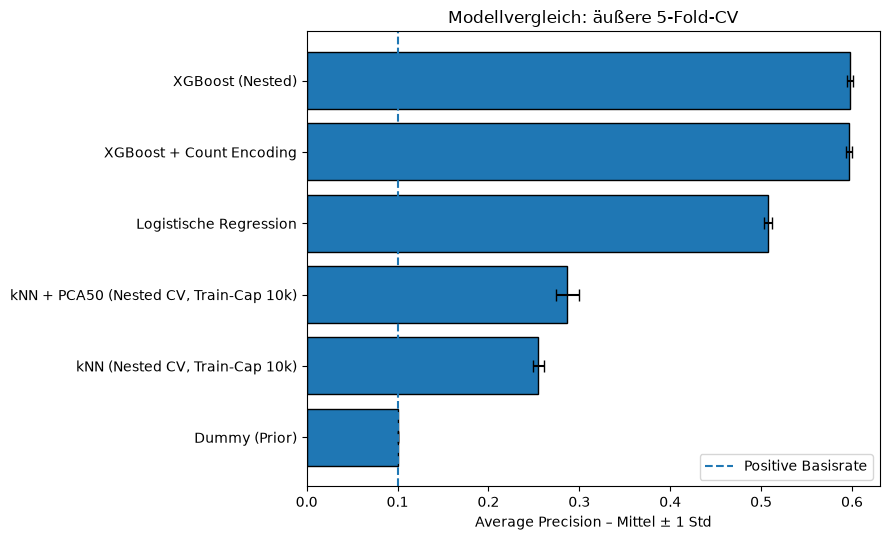

In [27]:
fig, ax = plt.subplots(figsize=(9, 5.5))

plot_table = fold_summary.sort_values("AP_Mittel")

ax.barh(
    plot_table.index,
    plot_table["AP_Mittel"],
    xerr=plot_table["AP_Std"],
    capsize=4,
    edgecolor="black",
)

ax.axvline(
    y_dev.mean(),
    linestyle="--",
    label="Positive Basisrate",
)

ax.set_title("Modellvergleich: äußere 5-Fold-CV")
ax.set_xlabel("Average Precision – Mittel ± 1 Std")
ax.legend()

plt.tight_layout()

save_figure(
    fig,
    "model_comparison_ap",
)

plt.show()

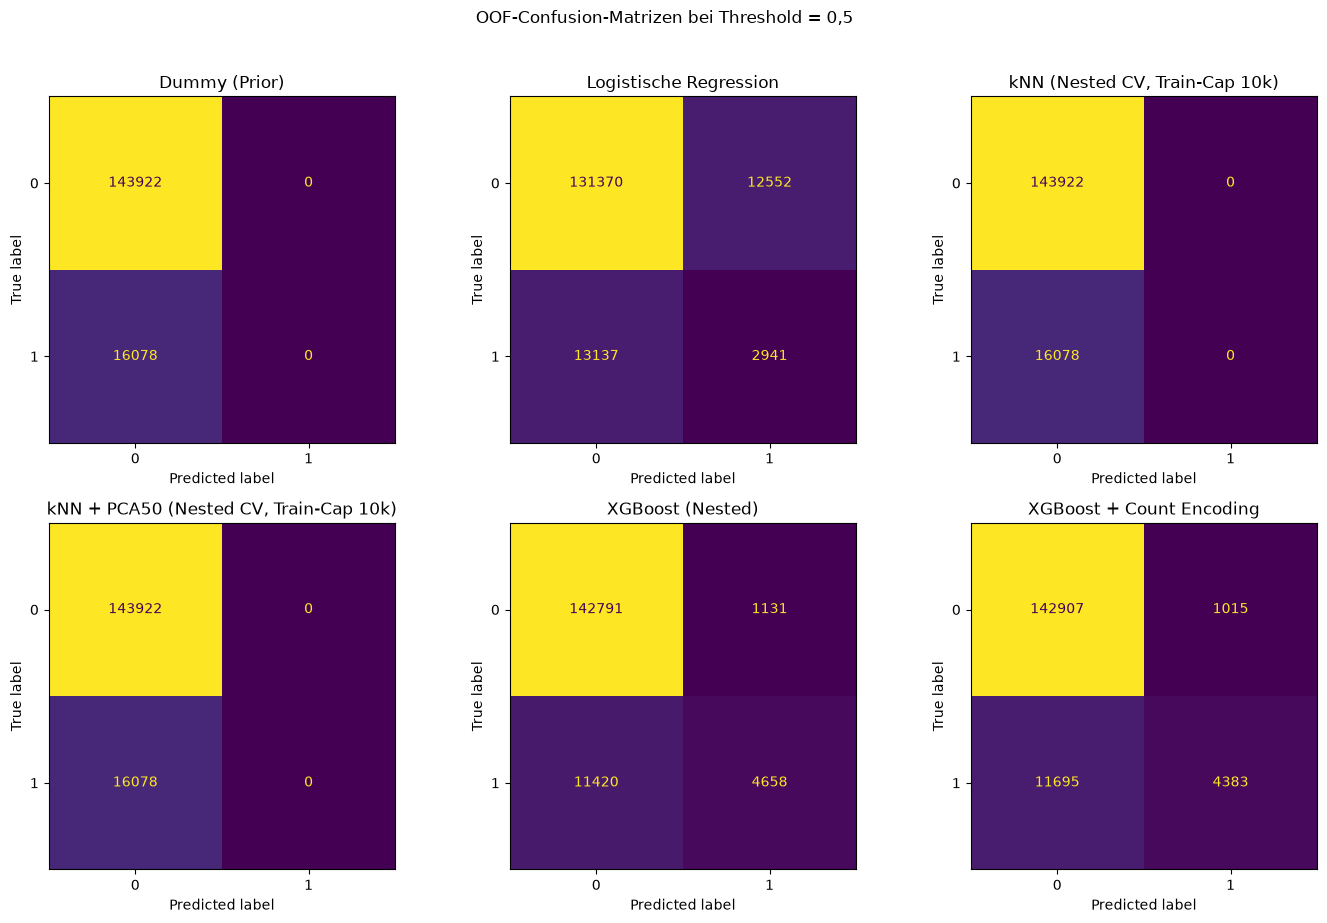

In [28]:
confusion_models = [
    "Dummy (Prior)",
    "Logistische Regression",
    "kNN (Nested CV, Train-Cap 10k)",
    "kNN + PCA50 (Nested CV, Train-Cap 10k)",
    "XGBoost (Nested)",
    "XGBoost + Count Encoding",
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 9),
)

for ax, name in zip(
    axes.ravel(),
    confusion_models,
):
    probabilities = oof_predictions[name].to_numpy()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_dev,
        predictions,
        labels=[0, 1],
        display_labels=["0", "1"],
        values_format="d",
        colorbar=False,
        ax=ax,
    )

    ax.set_title(name)

fig.suptitle(
    "OOF-Confusion-Matrizen bei Threshold = 0,5",
    y=1.02,
)

plt.tight_layout()

save_figure(
    fig,
    "model_comparison_confusion_matrices",
)

plt.show()

Die Confusion Matrices zeigen ergänzend das Klassifikationsverhalten der
Modelle bei einem einheitlichen Threshold von `0,5`.

Da die Ergebnisse einer Confusion Matrix vom gewählten Threshold abhängen,
werden sie nicht für die eigentliche Modellauswahl verwendet. Der Einfluss des
Thresholds wird später für das ausgewählte XGBoost-Modell separat untersucht.

**Ergebnis:** XGBoost erreicht mit etwa `0,5977 ± 0,0030` die höchste mittlere
Average Precision und ist damit das stärkste der untersuchten Modelle.

Bereits die logistische Regression erreicht mit etwa `0,5076 ± 0,0042` eine
deutlich höhere Leistung als die Dummy-Baseline mit ungefähr `0,1005`.

Das getestete kNN-Setup liegt deutlich darunter. Durch PCA verbessert sich die
Average Precision zwar von `0,2549` auf `0,2866`, erreicht aber nicht die
Leistung der logistischen Regression oder von XGBoost.

Count Encoding verbessert die primäre Metrik Average Precision nicht. Deshalb wird das ursprüngliche
XGBoost-Modell ohne zusätzliche Count-Features für die weitere Analyse
verwendet.

# 14. Welche Features sind für XGBoost besonders wichtig?

Um das beste XGBoost-Modell genauer zu untersuchen, werden zwei verschiedene
Importance-Maße betrachtet.

Die Gain-Importance zeigt, welche Features XGBoost beim Aufbau der Bäume
besonders stark nutzt. Ergänzend wird mit Permutation Importance geprüft, wie
stark die Average Precision sinkt, wenn einzelne Features in den äußeren
Validierungsdaten zufällig vertauscht werden.

Die Importance-Werte beschreiben nur die Bedeutung für die Vorhersage des
Modells. Wegen der anonymisierten Features lassen sich daraus keine fachlichen
oder kausalen Aussagen ableiten.

Die Permutation Importance wird pro Outer-Fold auf einer zufälligen Stichprobe
von maximal 3.000 Validierungsbeobachtungen mit zwei Wiederholungen berechnet;
untersucht werden ausschließlich die 15 Features mit der höchsten
Gain-Importance.

In [29]:
best_xgb_name = "XGBoost (Nested)"

importance_array = np.vstack(xgb_gain_importances)

interpretation_artifacts = xgb_outer_artifacts

importance_feature_names = interpretation_artifacts[0]["feature_names"]

gain_table = pd.DataFrame({
    "Gain Mittel": importance_array.mean(axis=0),
    "Gain Std": importance_array.std(axis=0, ddof=1),
}, index=importance_feature_names).sort_values("Gain Mittel", ascending=False)

display(gain_table.head(20))

print("Interpretierte XGBoost-Variante:", best_xgb_name)

,Gain Mittel,Gain Std
var_81,0.0227,0.0016
var_139,0.0166,0.0015
var_12,0.0151,0.0009
var_110,0.0138,0.0010
var_26,0.0132,0.0004
var_53,0.0128,0.0007
var_80,0.0121,0.0008
var_146,0.0117,0.0006
var_6,0.0116,0.0004
var_166,0.0110,0.0008


Interpretierte XGBoost-Variante: XGBoost (Nested)


,AP_Abfall_Mittel,AP_Abfall_Std
Feature,,
var_81,0.0232,0.0086
var_26,0.0148,0.0033
var_6,0.0147,0.0061
var_12,0.0136,0.0071
var_139,0.0133,0.0081
var_53,0.0124,0.0054
var_110,0.0120,0.0048
var_146,0.0117,0.0054
var_166,0.0115,0.0038


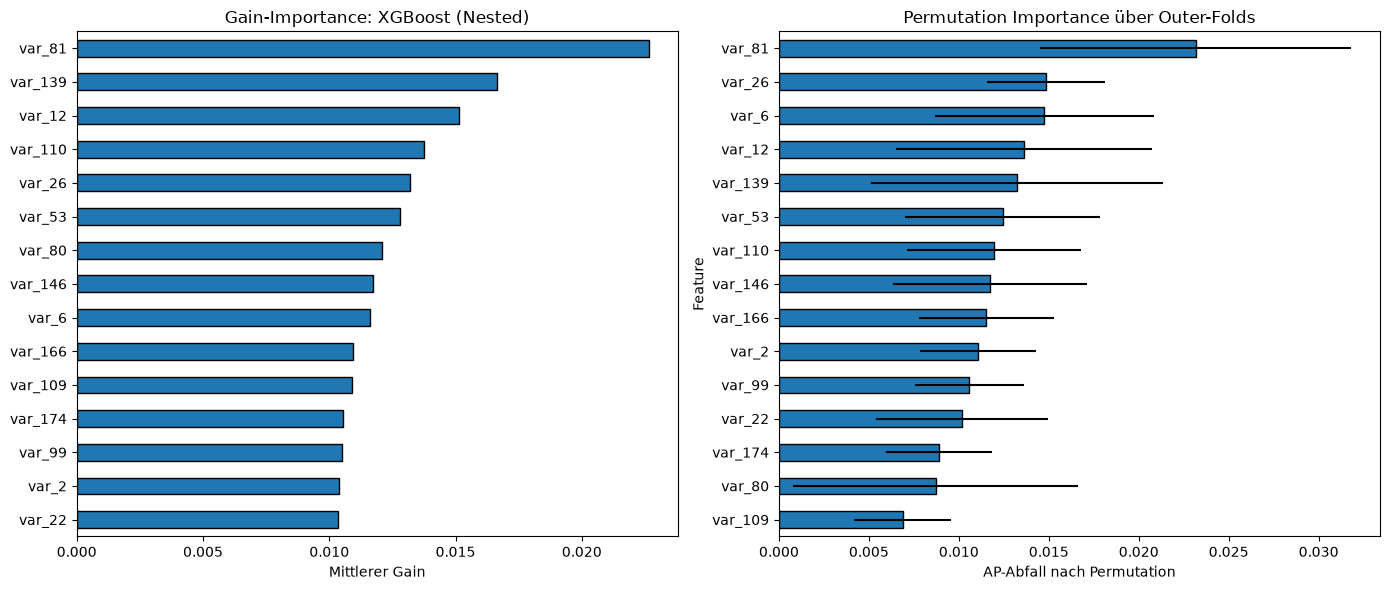

In [30]:
# Permutation Importance für die 15 stärksten Gain-Features
# über alle äußeren Validierungsfolds.
permutation_features = gain_table.head(15).index.tolist()
permutation_rng = np.random.default_rng(RANDOM_STATE + 800)
permutation_records = []

for artifact in interpretation_artifacts:
    X_validation = artifact["X_validation"]
    y_validation = artifact["y_validation"]
    model = artifact["model"]

    sample_size = min(3_000, len(X_validation))
    sample_positions = permutation_rng.choice(
        len(X_validation), size=sample_size, replace=False
    )
    X_sample = X_validation.iloc[sample_positions].copy()
    y_sample = y_validation.iloc[sample_positions]

    base_probability = model.predict_proba(X_sample)[:, 1]
    base_ap = average_precision_score(y_sample, base_probability)

    for feature in permutation_features:
        original_values = X_sample[feature].to_numpy(copy=True)
        drops = []
        for _ in range(2):
            X_sample[feature] = permutation_rng.permutation(original_values)
            permuted_probability = model.predict_proba(X_sample)[:, 1]
            drops.append(base_ap - average_precision_score(y_sample, permuted_probability))
        X_sample[feature] = original_values

        permutation_records.append({
            "Fold": artifact["fold"],
            "Feature": feature,
            "AP-Abfall": np.mean(drops),
        })

permutation_table = (
    pd.DataFrame(permutation_records)
    .groupby("Feature")
    .agg(
        AP_Abfall_Mittel=("AP-Abfall", "mean"),
        AP_Abfall_Std=("AP-Abfall", "std"),
    )
    .sort_values("AP_Abfall_Mittel", ascending=False)
)
display(permutation_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
gain_table.head(15).sort_values("Gain Mittel")["Gain Mittel"].plot(
    kind="barh", ax=axes[0], edgecolor="black"
)
axes[0].set_title(f"Gain-Importance: {best_xgb_name}")
axes[0].set_xlabel("Mittlerer Gain")

permutation_table.head(15).sort_values("AP_Abfall_Mittel").plot(
    y="AP_Abfall_Mittel",
    xerr="AP_Abfall_Std",
    kind="barh",
    ax=axes[1],
    legend=False,
    edgecolor="black",
)
axes[1].set_title("Permutation Importance über Outer-Folds")
axes[1].set_xlabel("AP-Abfall nach Permutation")

plt.tight_layout()
save_figure(fig, "xgboost_feature_importance")
plt.show()


**Ergebnis:** Mehrere Features, die bereits in der EDA deutliche Unterschiede
zwischen den Zielklassen gezeigt haben, gehören auch bei XGBoost zu den
wichtigsten Variablen.

Besonders `var_81` fällt erneut auf und besitzt sowohl eine hohe
Gain-Importance als auch eine hohe Permutation Importance. Auch weitere
Features aus der EDA-Rangliste treten bei XGBoost wieder auf.

Damit stimmen die univariate EDA und das multivariate Modell zumindest
teilweise überein. Die Importance-Werte zeigen jedoch nur, welche Features
XGBoost für seine Vorhersagen nutzt. Eine fachliche oder kausale Interpretation
ist aufgrund der Anonymisierung nicht möglich.

Die Permutation Importance wurde dabei nur für die 15 Features mit der höchsten
Gain-Importance berechnet.

# 15. Einfluss des Entscheidungsschwellenwerts

Die bisher verwendeten Kennzahlen AP und ROC-AUC bewerten die vorhergesagten
Wahrscheinlichkeiten unabhängig von einem festen Entscheidungsschwellenwert.

Für eine konkrete Klassenzuordnung muss jedoch ein Threshold festgelegt werden.
Deshalb wird der Standardwert `0,5` mit einem auf den OOF-Vorhersagen des
Development-Sets bestimmten Threshold verglichen.

Als technische Referenz wird der Threshold gewählt, bei dem der F1-Score
auf den OOF-Daten maximal ist.

,Policy,Threshold,Precision,Recall,F1,MCC,Specificity,Balanced Accuracy,Positiv vorhergesagt [%]
0,Standard 0.5,0.5000,0.8046,0.2897,0.4260,0.4538,0.9921,0.6409,3.6181
1,Maximales OOF-F1,0.2405,0.5520,0.5706,0.5612,0.5113,0.9483,0.7594,10.3869


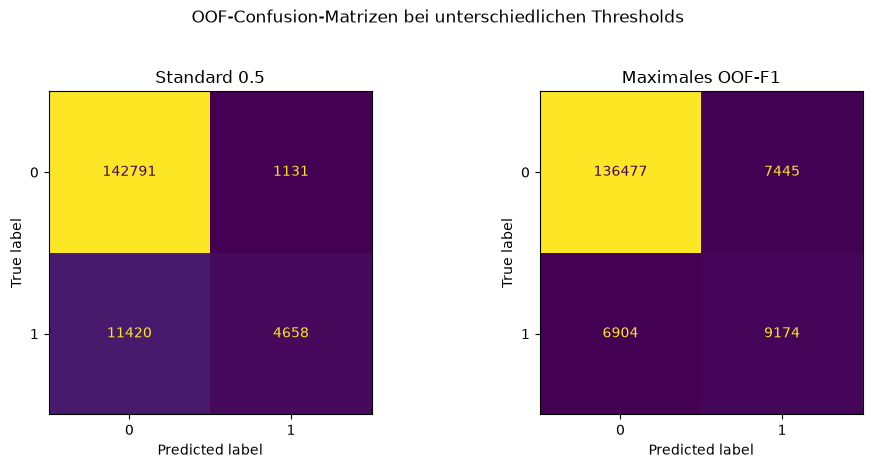

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
)

best_model_name = fold_summary["AP_Mittel"].idxmax()
assert best_model_name == "XGBoost (Nested)"

decision_probabilities = oof_predictions[best_model_name].to_numpy()

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_dev, decision_probabilities
)
f1_values = (
    2 * precision_curve[:-1] * recall_curve[:-1]
    / np.maximum(precision_curve[:-1] + recall_curve[:-1], 1e-12)
)
best_f1_idx = int(np.nanargmax(f1_values))
best_threshold = float(thresholds[best_f1_idx])


def threshold_metrics(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    matrix = confusion_matrix(y_true, predictions)
    tn, fp, _, _ = matrix.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "Threshold": threshold,
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "MCC": matthews_corrcoef(y_true, predictions),
        "Specificity": specificity,
        "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
        "Positiv vorhergesagt [%]": 100 * predictions.mean(),
    }, matrix


threshold_results = []
confusion_matrices = {}
for policy, threshold in {
    "Standard 0.5": 0.5,
    "Maximales OOF-F1": best_threshold,
}.items():
    metrics, matrix = threshold_metrics(y_dev, decision_probabilities, threshold)
    threshold_results.append({"Policy": policy, **metrics})
    confusion_matrices[policy] = matrix

threshold_results = pd.DataFrame(threshold_results)
display(threshold_results)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, (policy, matrix) in zip(
    axes,
    confusion_matrices.items(),
):
    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["0", "1"],
    ).plot(
        ax=ax,
        colorbar=False,
        values_format="d",
    )

    ax.set_title(policy)

fig.suptitle(
    "OOF-Confusion-Matrizen bei unterschiedlichen Thresholds",
    y=1.03,
)

plt.tight_layout()

save_figure(
    fig,
    "threshold_confusion_matrices_oof",
)

plt.show()

threshold_results.to_csv(RESULT_DIR / "threshold_metrics_oof.csv", index=False)


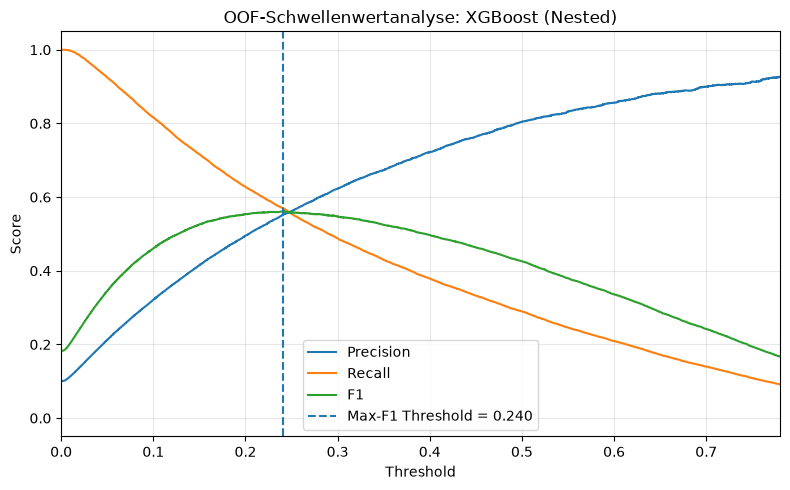

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precision_curve[:-1], label="Precision")
ax.plot(thresholds, recall_curve[:-1], label="Recall")
ax.plot(thresholds, f1_values, label="F1")
ax.axvline(best_threshold, linestyle="--", label=f"Max-F1 Threshold = {best_threshold:.3f}")
ax.set_title(f"OOF-Schwellenwertanalyse: {best_model_name}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_xlim(0, np.quantile(thresholds, 0.99))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure(fig, "threshold_analysis_oof")
plt.show()


**Ergebnis:** Beim Standard-Threshold von `0,5` erreicht XGBoost eine hohe
Precision von etwa `0,805`, erkennt aber nur ungefähr `29 %` der positiven
Fälle.

Der auf den OOF-Daten bestimmte Threshold von etwa `0,2405` erhöht den Recall
auf ungefähr `0,571`. Gleichzeitig sinkt die Precision auf etwa `0,552`.
Der F1-Score steigt dadurch von ungefähr `0,426` auf `0,561`.

Die Confusion Matrices zeigen denselben Effekt: Durch den niedrigeren Threshold
werden mehr positive Fälle erkannt, gleichzeitig steigt jedoch auch die Zahl
der False Positives.

Da keine fachlichen Kosten für False Positives und False Negatives bekannt
sind, wird `0,2405` nur als technische Referenz verwendet und nicht als
fachlich optimaler Entscheidungsschwellenwert interpretiert.

# 16. Finale Modellentscheidung vor dem Holdout

Bevor der finale Holdout ausgewertet wird, werden alle Modellentscheidungen
ausschließlich anhand der Development-Ergebnisse festgelegt.

Dazu werden die bevorzugten Konfigurationen der einzelnen Modelle sowie der
auf den OOF-Vorhersagen bestimmte Entscheidungsschwellenwert gespeichert.

Nach der Auswertung des Holdouts werden keine Hyperparameter, Features oder
Thresholds mehr verändert.

In [33]:
# Logistische Regression:
# häufigste gemeinsam gewählte Kombination aus C und class_weight
logistic_details = model_details["Logistische Regression"].copy()

logistic_selection = (
    logistic_details
    .assign(
        model__class_weight=logistic_details["model__class_weight"].fillna("None")
    )
    .groupby(["model__C", "model__class_weight"])
    .size()
    .sort_values(ascending=False)
)

logistic_final_c, logistic_final_class_weight = logistic_selection.index[0]
logistic_final_c = float(logistic_final_c)

if logistic_final_class_weight == "None":
    logistic_final_class_weight = None


# kNN:
# PCA50 war im direkten Fold-Vergleich in allen fünf Folds stärker
knn_details = model_details[
    "kNN + PCA50 (Nested CV, Train-Cap 10k)"
]

knn_final_config = "StandardScaler + PCA50"
knn_final_k = int(knn_details["k"].mode().iloc[0])
knn_final_weights = knn_details["weights"].mode().iloc[0]


# XGBoost:
# häufigster Gewinner der fold-internen Modellauswahl
xgb_details = model_details["XGBoost (Nested)"]

xgb_final_candidate = xgb_details["Kandidat"].mode().iloc[0]
assert xgb_final_candidate == "regularisiert_flach"

# Baumzahl nur aus den Folds ableiten, in denen genau dieser Kandidat gewann
selected_tree_counts = xgb_details.loc[
    xgb_details["Kandidat"].eq(xgb_final_candidate),
    "Bäume",
]

xgb_final_trees = int(round(selected_tree_counts.median()))
assert xgb_final_trees > 0

assert best_model_name == "XGBoost (Nested)"
assert 0 < best_threshold < 1

frozen_configuration = pd.DataFrame({
    "Komponente": [
        "Bestes Modell nach Outer-CV AP",
        "Entscheidungsschwelle",
        "LogReg C",
        "LogReg class_weight",
        "kNN Konfiguration",
        "kNN k",
        "kNN weights",
        "XGBoost Kandidat",
        "XGBoost Bäume",
    ],
    "Wert": [
        best_model_name,
        best_threshold,
        logistic_final_c,
        logistic_final_class_weight,
        knn_final_config,
        knn_final_k,
        knn_final_weights,
        xgb_final_candidate,
        xgb_final_trees,
    ],
})

frozen_configuration_display = frozen_configuration.copy()

frozen_configuration_display.loc[
    frozen_configuration_display["Komponente"].eq("LogReg C"),
    "Wert",
] = f"{logistic_final_c:.0e}"

display(frozen_configuration_display)

frozen_configuration.to_csv(
    RESULT_DIR / "frozen_configuration.csv",
    index=False,
)

print("Bestes Modell nach mittlerer Outer-CV AP:", best_model_name)
print(f"Eingefrorener OOF-Max-F1-Threshold: {best_threshold:.4f}")

,Komponente,Wert
0,Bestes Modell nach Outer-CV AP,XGBoost (Nested)
1,Entscheidungsschwelle,0.2405
2,LogReg C,1e-05
3,LogReg class_weight,None
4,kNN Konfiguration,StandardScaler + PCA50
5,kNN k,101
6,kNN weights,distance
7,XGBoost Kandidat,regularisiert_flach
8,XGBoost Bäume,1464


Bestes Modell nach mittlerer Outer-CV AP: XGBoost (Nested)
Eingefrorener OOF-Max-F1-Threshold: 0.2405


# 17. Finale Evaluation auf dem Holdout

Nach Abschluss der Modellwahl wird die zuvor eingefrorene XGBoost-Konfiguration
einmalig auf dem finalen Holdout ausgewertet.

Im finalen Analyseworkflow wurde der abgetrennte Holdout weder für EDA,
Hyperparameteroptimierung, Modellwahl noch für die Bestimmung des
Entscheidungsschwellenwerts verwendet.

FINALE HOLDOUT-EVALUATION
Modell: regularisiert_flach
Bäume: 1464
Threshold: 0.2405


,AP,ROC-AUC,Log Loss,Brier
XGBoost,0.5971,0.8918,0.2113,0.0604


,Threshold,Precision,Recall,F1,MCC,Specificity,Balanced Accuracy,Positiv vorhergesagt [%]
XGBoost,0.2405,0.5472,0.5697,0.5582,0.5079,0.9473,0.7585,10.4625


,Prognose 0,Prognose 1
Ist 0,34085,1895
Ist 1,1730,2290


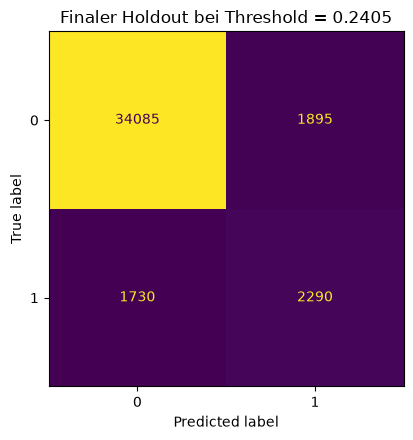

: 

In [ ]:
if ALLOW_FINAL_HOLDOUT_EVALUATION:
    assert best_model_name == "XGBoost (Nested)"
    assert xgb_final_candidate == "regularisiert_flach"
    assert xgb_final_trees > 0
    assert 0 < best_threshold < 1

    final_model = XGBClassifier(
        **XGB_COMMON,
        **XGB_CANDIDATES[xgb_final_candidate],
        n_estimators=xgb_final_trees,
    )

    final_model.fit(
        X_dev,
        y_dev,
        verbose=False,
    )

    holdout_probability = final_model.predict_proba(
        X_final_holdout
    )[:, 1]

    holdout_probability_results = pd.DataFrame(
        [probability_metrics(y_final_holdout, holdout_probability)],
        index=["XGBoost"],
    )

    holdout_threshold_metrics, holdout_matrix = threshold_metrics(
        y_final_holdout,
        holdout_probability,
        best_threshold,
    )

    holdout_threshold_results = pd.DataFrame(
        [holdout_threshold_metrics],
        index=["XGBoost"],
    )

    holdout_confusion_matrix = pd.DataFrame(
        holdout_matrix,
        index=["Ist 0", "Ist 1"],
        columns=["Prognose 0", "Prognose 1"],
    )

    print("FINALE HOLDOUT-EVALUATION")
    print(f"Modell: {xgb_final_candidate}")
    print(f"Bäume: {xgb_final_trees}")
    print(f"Threshold: {best_threshold:.4f}")

    display(holdout_probability_results)
    display(holdout_threshold_results)
    display(holdout_confusion_matrix)

    fig, ax = plt.subplots(figsize=(5, 4.5))

    ConfusionMatrixDisplay(
        confusion_matrix=holdout_matrix,
        display_labels=["Negativ (0)", "Positiv (1)"],
    ).plot(
        ax=ax,
        colorbar=False,
        values_format="d",
    )

    ax.set_xlabel("Vorhergesagte Klasse")
    ax.set_ylabel("Tatsächliche Klasse")
    ax.set_title(
        f"Finale Holdout-Evaluation bei Threshold = {best_threshold:.4f}"
    )

    plt.tight_layout()

    save_figure(
        fig,
        "final_holdout_confusion_matrix",
    )

    plt.show()

    holdout_probability_results.to_csv(
        RESULT_DIR / "final_holdout_probability_metrics.csv"
    )

    holdout_threshold_results.to_csv(
        RESULT_DIR / "final_holdout_threshold_metrics.csv"
    )

    holdout_confusion_matrix.to_csv(
        RESULT_DIR / "final_holdout_confusion_matrix.csv"
    )

else:
    print("Finaler Holdout bleibt GESPERRT.")

**Ergebnis:** Die XGBoost-Konfiguration und der Entscheidungsschwellenwert
wurden vor der finalen Auswertung ausschließlich auf den Development-Daten
festgelegt. Der Holdout wurde nicht für eine nachträgliche Optimierung
verwendet.

Auf dem finalen Holdout erreicht XGBoost eine Average Precision von etwa
`0,5971` und eine ROC-AUC von etwa `0,8918`. Die Holdout-AP liegt damit sehr
nahe an der mittleren AP der äußeren Cross-Validation von etwa `0,5977`; dies
spricht für eine stabile Generalisierungsleistung.

Beim zuvor festgelegten Threshold von etwa `0,2405` erreicht das Modell eine
Precision von etwa `0,547`, einen Recall von etwa `0,570` und einen F1-Score
von etwa `0,558`.

Von den `4.020` tatsächlich positiven Beobachtungen werden `2.290` korrekt
erkannt, während `1.730` positive Fälle übersehen werden. Gleichzeitig werden
`1.895` negative Beobachtungen fälschlicherweise als positiv klassifiziert
(`34.085` True Negatives).

# 18. Fazit

XGBoost erzielt die beste Vorhersageleistung der untersuchten Modelle. Die
nahezu identische Average Precision in der äußeren Cross-Validation (`0,5977`)
und auf dem finalen Holdout (`0,5971`) spricht für eine stabile
Generalisierungsleistung. Die logistische Regression liegt deutlich über der
Dummy-Baseline und den getesteten kNN-Varianten und bildet damit eine starke
lineare Baseline. PCA verbessert kNN zwar, dessen Leistung bleibt jedoch unter
der logistischen Regression und XGBoost. Das zusätzliche Count Encoding bringt
hinsichtlich der primären Average Precision keinen Vorteil. Die anonymisierten
Features verhindern eine fachliche oder kausale Interpretation; falls fachlich
begründete Kosten für False Positives und False Negatives verfügbar werden,
wäre eine kostenbasierte Wahl des Entscheidungsschwellenwerts der sinnvolle
nächste Schritt.